# Knee MRI preprocessing: supervised studies only

This notebook preprocesses **verified-label studies and studies with at least one accepted generated target**. A generated target must have a binary value, mask=1 and positive training weight. Studies with no usable labels are excluded before sharding, source-file scans or DICOM decoding. Every series of an eligible study is retained for processing; partially labeled studies remain useful because the training loss masks unknown targets.

Folds are assigned first, on the full study table, so verified validation studies remain included and existing study/patient separation is preserved. The GPU file is `qwen_training_labels.csv`, not raw extractions. Set `USE_GPU_LABELS=False` for verified-only preprocessing.

## Full supervised preprocessing

1. Attach competition data and the accepted GPU label dataset.
2. Run the metadata and planning cells. They print retained/skipped study counts, eligible series, estimated cache size, and shard assignments **without reading image pixels**.
3. With `MAX_STUDIES=None`, process `SHARD_INDEX=0`. `NUM_SHARDS=None` automatically chooses a deterministic plan using eligible series and a 4.7 GB target per shard. The earlier 56.6 GB full-dataset estimate is only used to estimate average bytes per series.
4. Let automatic publication finish and wait for Kaggle dataset processing, then use a fresh session for the next printed shard index. Keep identical labels, code and shard settings. If pending series remain, resume that shard first.
5. Attach the cumulative dataset and use the section 8 loader for training; inspect `study_preprocessing_selection.csv` and the saved shard plan to verify coverage. Do not mix the previous unfiltered manifests with this plan. Existing image caches may be reused when their run ID matches; this revision changes the transform and requires rerunning shard 0.

Orientation deviations above 35° remain review warnings. All other geometry/decoding checks remain enforced, and incomplete studies are excluded from training-ready manifests. Images remain native-plane 64 × 320 × 320 tensors with slice/series masks. Estimates are not storage guarantees; time, memory and disk guards remain active.

For a 12-study supervised pilot, set `MAX_STUDIES=12` and `NUM_SHARDS=1`.


## Automatic dataset publishing

`AUTO_PUBLISH=True` publishes after each shard to the single private dataset **gany24558/rsna-knee-normalized-training-data**. Each new version includes existing shard packages plus the current shard; stable filenames prevent collisions, while cumulative upload preserves earlier contents. KaggleHub retrieves the latest published version first. Do not run simultaneous publishers.

Wait for dataset processing before the next shard. The final training dataset is ready only after all shard entries are processed. Partial snapshots are backups, not complete training data. The loader in section 8 reads the published packages without unpacking the entire dataset. Incompatible shards are never mixed. This revision explicitly migrates only the reviewed legacy shard 0: it retains that package under a legacy filename, starts a new active preprocessing generation, and uses the same dataset handle. Labels and the shard plan must match. Other identity changes are blocked.

[Publishing API reference](https://github.com/Kaggle/kagglehub#upload-a-dataset).

## Full-field-of-view resizing update

Rerun **shard 0 first**, in a fresh Kaggle session. The old package is archived and excluded from training; the corrected shard is recomputed under a new cache identity. Then run shards 1–11 using this same notebook and settings after each publication finishes processing.

Images use 0.75 mm in-plane spacing when they fit. For larger scans, increase spacing equally in both directions just enough to fit the complete source pixel-center extent into 320 × 320. This preserves aspect ratio and avoids centered cropping; it reduces resolution for those scans. Actual spacing is stored in each cache, manifest and training batch. Shape remains 64 × 320 × 320. Other geometry checks and the complete-study requirement remain active.


In [3]:
# Install before imports. Kaggle normally provides numpy/scipy/pandas/torch/matplotlib.
import subprocess, sys
INSTALL_DICOM_DEPENDENCIES = True
if INSTALL_DICOM_DEPENDENCIES:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
        'pydicom==3.0.1', 'pylibjpeg>=2,<3', 'pylibjpeg-libjpeg>=2,<3',
        'pylibjpeg-openjpeg>=2,<3', 'pyjpegls>=1.2,<2', 'kagglehub>=0.4.1,<1'])
# If pip reports replacement of an already imported NumPy, restart the kernel.
# Offline: attach compatible wheels and install with --no-index --find-links.

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 47.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 60.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 79.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.6/70.6 kB 5.0 MB/s eta 0:00:00


## 1. Configuration

The defaults bound the first run. A full cache may exceed one Kaggle session's output capacity. Sharding is deterministic by study, so all series for a study stay in one shard. Storage guards count new cache bytes and preserve reserve space; they cannot guarantee the platform's output-upload quota.

`RESUME_CACHE_ROOTS` points to attached **cache/** directories containing `<run_id>/*.npz`. Settings and implementation changes create a new cache identity. Keep the source competition version immutable: cache source signatures use slice names, sizes, and timestamps, not full pixel hashes.

`fit_full_fov=True` automatically increases in-plane spacing only for scans that exceed the fixed canvas. Both axes use the same spacing to preserve aspect ratio. `spacing_mm` is the minimum requested spacing, not a promise that every scan has that spacing. Keep `max_crop_fraction=0.0`; the full-FOV fallback should satisfy this guard. Increasing `size` can preserve more spatial resolution at a higher memory cost.

In [4]:
from pathlib import Path
DATA_DIR = None  # Auto-discover; or Path('/kaggle/input/...')
LABELS_CSV = None  # Auto-discover qwen_training_labels.csv; ambiguous inputs cause an error.
USE_GPU_LABELS = True  # False = verified-only baseline.
PATIENT_GROUPS_CSV = None  # Optional CSV with StudyInstanceUID,PatientGroup.
OUTPUT_DIR = Path('/kaggle/working/knee_preprocessed_supervised')
RESUME_CACHE_ROOTS = []  # e.g. Path('/kaggle/input/my-cache-shard/cache')
MAX_STUDIES = None  # Full selected shard; use 12 and NUM_SHARDS=1 for a pilot.
NUM_SHARDS = None  # Automatically planned from eligible series only.
TARGET_SHARD_GB = 4.7
ESTIMATED_BYTES_PER_SERIES = 56.6e9 / 24371  # Previous pilot; estimate, not a guarantee.
SHARD_INDEX = 11  # Run the indices printed in the supervised shard plan.
REVIEW_PREVIEW_LIMIT = 12  # All flagged rows remain in the review CSV.
MAX_HOURS = 2.0
MAX_NEW_CACHE_GB = 8.0
MIN_FREE_DISK_GB = 3.0
N_FOLDS = 5
VALIDATION_FOLD = 0
SEED = 42
CFG = dict(depth=64, size=320, spacing_mm=0.75,
           percentiles=[0.5,99.5], gap_tolerance=0.05,
           max_obliquity_degrees=35, max_crop_fraction=0.0, fit_full_fov=True,
           min_valid_fraction=0.05, antialias=True, max_working_memory_gb=2.0,
           intensity_sample_pixels=250_000)
AUTO_PUBLISH = True
PREPROCESSED_DATASET_HANDLE = 'gany24558/rsna-knee-normalized-training-data'
# One-time migration of the reviewed legacy shard 0; all other mismatches fail.
FOV_MIGRATION_FROM_RUN_ID = 'ab9ab310a4bd462b348f'


## 2. Native-plane preprocessing helpers

Run these small cells in order. Physical positions determine ordering; missing, mixed or irregular geometry is reported as an error. Source obliquity is preserved. The in-plane transform is a signed axis permutation with physical scaling, never a rotation through neighboring slices.

Two streaming passes estimate intensity limits and decode the selected source slices. A conservative per-slice/output working-memory estimate replaces the full-volume guard. Cached metadata records exact selected SOP IDs, source indices, slice positions, output origins and in-plane basis vectors. A single uniform 3D affine does not describe a nonuniformly sampled series.

In [5]:
from pathlib import Path
import hashlib, json, time, os, shutil, itertools
import tarfile
import io
from functools import lru_cache
import numpy as np
import pandas as pd
import scipy
from scipy.ndimage import affine_transform, gaussian_filter
import pydicom
from pydicom.pixels import apply_modality_lut

ID = 'StudyInstanceUID'
SID = 'SeriesInstanceUID'
LABELS = ['ACL', 'MCL', 'Medial Meniscus', 'Lateral Meniscus', 'Medial OA',
          'Lateral OA', 'PF OA', 'Effusion', 'Synovitis', "Baker's", 'Contusion', 'Fracture']
# Columns are output depth, row, column directions in DICOM LPS coordinates.
AXES = {
    'Sagittal': np.array([[1,0,0], [0,0,1], [0,-1,0]], float),
    'Coronal': np.array([[0,0,1], [1,0,0], [0,-1,0]], float),
    'Axial': np.array([[0,0,1], [0,1,0], [1,0,0]], float),
}


### Digest

In [6]:
"""
generates a unique, secure, fixed-length "fingerprint" (hash) for any Python data structure, 
such as a dictionary, list, or text value.
"""
def digest(value):
    return hashlib.sha256(json.dumps(value, sort_keys=True, default=str).encode()).hexdigest()

### Atomic json

In [7]:
"""
This function writes a Python dictionary or list into a JSON file safely and atomically, 
protecting your data from corruption if the script crashes or is interrupted while writing.
"""
def atomic_json(path, value):
    path = Path(path)
    temp = path.with_suffix(path.suffix + '.tmp')
    temp.write_text(json.dumps(value, indent=2, allow_nan=False))
    temp.replace(path)

### Geometry

In [1]:
def validate_and_extract_geometry(headers, expected_study, expected_series, plane, cfg):
    """
    Validates DICOM header geometry, checks for spatial consistency, checks 
    slice-spacing consistency within configured tolerances, and extracts the physical coordinate basis matrix.
    
    Parameters:
        headers (list): List of pydicom dataset headers for a single series.
        expected_study (str): Expected StudyInstanceUID for validation.
        expected_series (str): Expected SeriesInstanceUID for validation.
        plane (str): Expected anatomical plane ('Sagittal', 'Coronal', 'Axial').
        cfg (dict): Pipeline configuration dictionary containing tolerances.
        
    Returns:
        dict: Spatial metadata including slice order, origin, basis matrix, and warnings.
    """
    if plane not in AXES:
        raise ValueError(f"Unknown plane: {plane}")
    if len(headers) < 2:
        raise ValueError("Need at least two spatial slices")

    first = headers[0]
    
    # iop is an array of 6 floating-point numbers (standard medical imaging metadata):
    # - The first 3 values (iop[:3]): Direction cosines for the image row.
    # - The last 3 values (iop[3:]): Direction cosines for the image column.
    iop = np.asarray(first.ImageOrientationPatient, float)
    
    spacing = np.asarray(first.PixelSpacing, float)

    # 1. Validate initial orientation and spacing parameters
    if iop.shape != (6,) or not np.isfinite(iop).all():
        raise ValueError("Invalid orientation")
    if spacing.shape != (2,) or not np.isfinite(spacing).all() or min(spacing) <= 0:
        raise ValueError("Invalid pixel spacing")

    col, row = iop[:3], iop[3:]
    if (
        abs(np.linalg.norm(col) - 1) > 1e-3
        or abs(np.linalg.norm(row) - 1) > 1e-3
        or abs(col @ row) > 1e-3
    ):
        raise ValueError("Orientation vectors are not orthonormal")

    normal = np.cross(col, row)
    photo = str(first.PhotometricInterpretation)
    if photo not in {"MONOCHROME1", "MONOCHROME2"}:
        raise ValueError("Only monochrome MRI supported")

    shape = (int(first.Rows), int(first.Columns))
    positions = []
    sops = []

    # 2. Iterate and validate consistency across all slices in the series
    for h in headers:
        if str(h.StudyInstanceUID) != expected_study or str(h.SeriesInstanceUID) != expected_series:
            raise ValueError("DICOM study/series ID mismatch")
        if int(getattr(h, "NumberOfFrames", 1)) != 1:
            raise ValueError("Enhanced/multiframe DICOM unsupported")
        if int(getattr(h, "SamplesPerPixel", 1)) != 1:
            raise ValueError("Non-grayscale DICOM")
        if (int(h.Rows), int(h.Columns)) != shape:
            raise ValueError("Mixed dimensions within series")
        if not np.allclose(h.ImageOrientationPatient, iop, atol=1e-4, rtol=0):
            raise ValueError("Mixed orientations within series")
        if not np.allclose(h.PixelSpacing, spacing, atol=1e-4, rtol=0):
            raise ValueError("Mixed pixel spacing within series")
        if str(h.PhotometricInterpretation) != photo:
            raise ValueError("Mixed photometric interpretation")
        
        positions.append(np.asarray(h.ImagePositionPatient, float))
        sops.append(str(h.SOPInstanceUID))

    if len(set(sops)) != len(sops):
        raise ValueError("Duplicate SOP instances")

    positions = np.asarray(positions)
    if positions.shape != (len(headers), 3) or not np.isfinite(positions).all():
        raise ValueError("Missing/nonfinite slice position")

    # 3. Sort slice positions and evaluate spatial gaps
    order = np.argsort(positions @ normal, kind="stable")
    positions = positions[order]
    distances = positions @ normal
    gaps = np.diff(distances)
    dz = float(np.median(gaps))

    if dz <= 0 or min(gaps) < 1e-3:
        raise ValueError("Duplicate/non-spatial slice positions")
    if np.max(abs(gaps - dz)) > max(0.05, cfg["gap_tolerance"] * dz):
        raise ValueError("Irregular slice spacing / missing slices; not silently interpolated")

    residual = positions - (positions[0] + np.arange(len(headers))[:, None] * dz * normal)
    if np.linalg.norm(residual, axis=1).max() > 0.2:
        raise ValueError("Nonparallel / shifted slice stack")

    # 4. Compute anatomical obliquity and flag warnings if needed
    angle = float(np.degrees(np.arccos(np.clip(abs(normal @ AXES[plane][:, 0]), 0, 1))))
    nearest = min(AXES, key=lambda p: np.degrees(np.arccos(np.clip(abs(normal @ AXES[p][:, 0]), 0, 1))))
    
    review_warning = ""
    if angle > cfg["max_obliquity_degrees"]:
        review_warning = (
            f"Orientation review: {angle:.1f} degrees from listed {plane}; "
            f"warning threshold {cfg['max_obliquity_degrees']:.1f}; nearest plane {nearest}. "
            "Native acquisition retained; plane label unchanged."
        )

    # 5. Construct the final 3D coordinate basis matrix
    basis = np.column_stack([normal * dz, row * spacing[0], col * spacing[1]])
    
    return dict(
        order=order, origin=positions[0], basis=basis,
        shape=(len(headers), *shape), photo=photo, angle=angle, dz=dz,
        review_warning=review_warning, nearest_plane=nearest,
        slice_thickness=float(getattr(first, "SliceThickness", 0) or 0)
    )

### Native grid

In [9]:
def native_grid(g, plane, cfg):
    """
    Performs spatial normalization on individual scan slices. It aligns, scales, 
    and computes the 2D affine transformation matrices needed to map heterogeneous 
    scanner layouts onto a uniform, standardized output grid without arbitrary 3D rotations.
    
    Parameters:
        g (dict): Spatial metadata dictionary extracted from geometry validation.
        plane (str): Expected anatomical plane ('Sagittal', 'Coronal', 'Axial').
        cfg (dict): Pipeline configuration dictionary containing target size and spacing.
        
    Returns:
        tuple: (matrix, offset, basis, crop) used for downstream image resampling.
    """
    # 1. Select native in-plane axes without through-plane interpolation or arbitrary rotations
    native = g['basis'][:, 1:]
    unit = native / np.linalg.norm(native, axis=0)
    
    # 2. Test valid axis permutations and sign flips to match the target anatomical orientation
    choices = []
    for perm in [(0, 1), (1, 0)]:
        for signs in itertools.product([-1, 1], repeat=2):
            directions = unit[:, perm] * np.array(signs)
            score = float(np.sum(directions * AXES[plane][:, 1:]))
            choices.append((score, directions))
            
    directions = max(choices, key=lambda x: x[0])[1]
    shape = np.array(g['shape'][1:])
    
    # 3. Calculate physical dimensions (extent) of the scan field of view (FOV)
    corners = np.array(list(itertools.product(*[(0, n - 1) for n in shape])))
    projections = (corners @ native.T) @ directions
    extent = np.ptp(projections, axis=0)
    
    # 4. Determine pixel spacing, optionally scaling to fit the full FOV while preserving aspect ratio
    spacing = float(cfg['spacing_mm'])
    if cfg.get('fit_full_fov', False):
        spacing = max(spacing, float(extent.max()) / (cfg['size'] - 1))
        
    # 5. Compute the 2D affine transformation matrix:
    #    The resampling matrix maps output pixel coordinates back to native source coordinates 
    #    using scaling, axis swaps and flips; offset supplies the translation. No arbitrary rotation is used.
    basis = directions * spacing
    matrix = np.linalg.pinv(native) @ basis
    matrix[np.abs(matrix) < 1e-10] = 0
    matrix = np.where(np.abs(matrix - np.rint(matrix)) < 1e-10, np.rint(matrix), matrix)
    
    # 6. Calculate centering offsets (translation part of the spatial alignment)
    center = (shape - 1) / 2
    offset = center - matrix @ np.full(2, (cfg['size'] - 1) / 2)
    offset[np.abs(offset) < 1e-10] = 0
    offset = np.where(np.abs(offset - np.rint(offset)) < 1e-10, np.rint(offset), offset)
    
    # 7. Validate safety constraints to ensure excessive cropping does not occur
    crop = np.maximum(0, 1 - (cfg['size'] - 1) * spacing / np.maximum(extent, 1e-9))
    if crop.max() > cfg['max_crop_fraction'] + 1e-8:
        raise ValueError(f'Native FOV crop would be {crop.max():.1%}; increase size/spacing')
        
    return matrix, offset, basis, crop

### Decode native slice

In [10]:
def decode_native_slice(path):
    """
    Loads an individual DICOM slice file, masks out background padding values, 
    applies the DICOM modality LUT or rescale parameters, and returns the processed float32 
    image alongside a validity mask.
    
    Parameters:
        path (str or Path): File path to the DICOM slice.
        
    Returns:
        tuple: (image, valid_mask)
            - image (np.ndarray): 32-bit floating-point array after modality scaling; MRI values need not have standardized physical units.
            - valid_mask (np.ndarray): Boolean mask filtering out padding and non-finite values.
    """
    # 1. Load the DICOM file and validate that the pixel array is strictly 2D
    ds = pydicom.dcmread(path)
    raw = ds.pixel_array
    if raw.ndim != 2:
        raise ValueError("Expected single-frame 2D pixels")
        
    # 2. Mask explicit DICOM padding values; this does not identify all air or anatomical background
    valid = np.ones(raw.shape, bool)
    if hasattr(ds, "PixelPaddingValue"):
        a = float(ds.PixelPaddingValue)
        b = float(getattr(ds, "PixelPaddingRangeLimit", a))
        valid &= (raw < min(a, b)) | (raw > max(a, b))
        
    # 3. Apply the modality LUT or rescale slope/intercept when supplied by the DICOM metadata
    image = apply_modality_lut(raw, ds).astype(np.float32)
    
    # 4. Return the calibrated image and combine the padding mask with a finite-value check
    return image, valid & np.isfinite(image)

### Series intensity limits

In [11]:
def series_intensity_limits(paths, cfg):
    """
    Calculates robust global pixel intensity clipping bounds across an entire series 
    of DICOM slices using a memory-efficient, deterministic sampling strategy.
    
    Parameters:
        paths (list): List of file paths to the DICOM slices in the series.
        cfg (dict): Pipeline configuration containing sampling targets and percentile definitions.
        
    Returns:
        tuple: (low, high) floating-point intensity limits for outlier clipping.
    """
    # 1. Determine a memory-efficient pixel sample budget per slice to prevent RAM spikes
    per_slice = max(1, cfg['intensity_sample_pixels'] // len(paths))
    samples = []
    
    # 2. Iterate through each slice, decode, and extract evenly-spaced valid pixel samples
    for path in paths:
        image, valid = decode_native_slice(path)
        values = image[valid]
        if len(values):
            # Select an evenly distributed subset of pixels using linear spacing
            ix = np.linspace(0, len(values) - 1, min(per_slice, len(values))).astype(int)
            samples.append(values[ix])
            
    # 3. Validate that a sufficient number of valid pixels were collected across the series
    if not samples or sum(map(len, samples)) < 32:
        raise ValueError('Insufficient valid pixels')
        
    # 4. Compute lower and upper percentiles (configured here as 0.5th and 99.5th) to establish robust intensity bounds
    low, high = np.percentile(np.concatenate(samples), cfg['percentiles'])
    
    # 5. Verify that the calculated limits are finite numbers and form a non-degenerate range
    if not np.isfinite([low, high]).all() or high <= low:
        raise ValueError('Constant/invalid series intensity')
        
    return float(low), float(high)

### Normalize native slice

In [12]:
def normalize_native_slice(image, valid, photo, low, high, matrix, offset, cfg):
    """
    Normalizes pixel intensities, handles photometric inversion, applies 
    conditional anti-aliasing for downsampling, and resamples the 2D slice 
    onto the standardized output grid using an affine transformation.
    
    Parameters:
        image (np.ndarray): 32-bit floating-point raw slice image.
        valid (np.ndarray): Boolean validity mask for the image pixels.
        photo (str): Photometric interpretation (e.g., 'MONOCHROME1' or 'MONOCHROME2').
        low (float): Lower intensity clipping threshold.
        high (float): Upper intensity clipping threshold.
        matrix (np.ndarray): 2D affine transformation matrix.
        offset (np.ndarray): Affine translation offset.
        cfg (dict): Pipeline configuration containing target size, antialiasing flags, etc.
        
    Returns:
        tuple: (output_slice, support_mask)
            - output_slice (np.ndarray): 16-bit floating-point normalized and resampled image.
            - support_mask (np.ndarray): Boolean support mask indicating valid resampled pixels.
    """
    # 1. Scale pixel values into a [0, 1] range using global intensity limits and clip outliers
    image = np.clip((image - low) / (high - low), 0, 1).astype(np.float32)
    
    # 2. Invert pixel intensities if photometric interpretation is MONOCHROME1 (lower values are intended to display brighter)
    if photo == 'MONOCHROME1':
        image = 1 - image
        
    # 3. Force invalid or background padding pixels to zero
    image[~valid] = 0
    
    # 4. Apply conditional anti-aliasing via Gaussian smoothing for in-plane reductions (downsampling)
    #    Anti-alias only in-plane reductions; no filtering is ever applied along depth.
    sigma = .5 * np.sqrt(np.maximum(np.sum(matrix ** 2, axis=1) - 1, 0))
    if cfg['antialias'] and sigma.max() > 0:
        numerator = gaussian_filter(image, sigma, mode='constant', cval=0)
        denominator = gaussian_filter(valid.astype(np.float32), sigma, mode='constant', cval=0)
        image = np.divide(numerator, denominator, out=np.zeros_like(numerator), where=denominator > 1e-6)
        
    # 5. Resample the image and validity mask onto the standardized target grid using affine transformations
    shape = (cfg['size'], cfg['size'])
    output = affine_transform(image, matrix, offset, output_shape=shape, order=1, mode='constant', cval=0, prefilter=False)
    support = affine_transform(valid.astype(np.float32), matrix, offset, output_shape=shape, order=1, mode='constant', cval=0, prefilter=False) > .999
    
    # 6. Zero out unsupported regions, ensure all values are finite, clip, and cast to float16 for memory efficiency
    output[~support] = 0
    if not np.isfinite(output).all():
        raise ValueError('Nonfinite output')
        
    return np.clip(output, 0, 1).astype(np.float16), support

### Select native indices

In [13]:
def select_native_indices(n, depth):
    """
    Selects a uniform subset of slice indices from a 3D scan volume to match 
    a target depth, ensuring both ends of the volume are always included.
    
    Parameters:
        n (int): Total number of available native slices in the series.
        depth (int): Target number of slices required by the pipeline configuration.
        
    Returns:
        np.ndarray: 1D array of unique integer slice indices.
    """
    # 1. If the total available slices are fewer than or equal to the target depth, return all indices
    if n <= depth:
        return np.arange(n, dtype=int)
        
    # 2. Otherwise, use linear spacing to select evenly distributed actual slices across the volume
    #    (guaranteeing inclusion of both endpoints without artificial duplication or interpolation)
    indices = np.rint(np.linspace(0, n - 1, depth)).astype(int)
    
    # 3. Assert that all selected indices are unique to prevent overlapping or repeated slices
    assert len(np.unique(indices)) == depth
    
    return indices

### Process series

In [14]:
def process_series(folder, study, series, plane, cfg):
    """
    Orchestrates the end-to-end preprocessing pipeline for a 3D DICOM series folder, 
    handling file discovery, fast header parsing, spatial validation, orientation 
    normalization, and cache array generation.
    
    Parameters:
        folder (str or Path): Directory path containing the DICOM series files.
        study (str): Study identifier.
        series (str): Series identifier.
        plane (str): Target anatomical viewing plane.
        cfg (dict): Pipeline configuration dictionary.
        
    Returns:
        tuple: (normalized image array, valid-pixel mask, metadata dictionary).
    """
    # 1. Discover and sort all DICOM files in the directory; raise an error if none are found
    paths = sorted(Path(folder).glob('*.dcm'))
    if not paths:
        raise FileNotFoundError(f'No DICOM slices in {folder}')
        
    # 2. Efficiently parse DICOM headers across all files without loading heavy pixel data into RAM
    headers = [pydicom.dcmread(p, stop_before_pixels=True) for p in paths]
    
    # 3. Extract and validate spatial geometry and orientation from the headers
    g = validate_and_extract_geometry(headers, study, series, plane, cfg)
    
    # 4. Reverse slice order if needed so the native normal has nonnegative projection on the listed plane normal
    if g['basis'][:, 0] @ AXES[plane][:, 0] < 0:
        g['origin'] = g['origin'] + g['basis'][:, 0] * (len(paths) - 1)
        g['basis'][:, 0] *= -1
        g['order'] = g['order'][::-1]
        
    # 5. Compute transformation matrices, offsets, and cropping parameters for the native grid
    matrix, offset, basis, crop = native_grid(g, plane, cfg)
    
    # 6. Reorder file paths based on the validated spatial sequence and select target depth slice indices
    ordered = [paths[i] for i in g['order']]
    indices = select_native_indices(len(paths), cfg['depth'])
    
    # 7. Execute the final slice-by-slice processing and build the native cache arrays
    return build_native_cache_arrays(ordered, headers, g, indices, matrix, offset, basis, crop, cfg)

### Build native cache arrays

In [15]:
def build_native_cache_arrays(paths, headers, g, indices, matrix, offset, basis, crop, cfg):
    """
    Executes the streaming core processing loop with an estimated-memory guard for selected slices, normalizes 
    and resamples each slice onto the target grid, validates valid-pixel coverage, 
    and compiles a comprehensive metadata audit log.
    
    Parameters:
        paths (list): Sorted list of file paths to DICOM slices.
        headers (list): List of parsed DICOM dataset headers.
        g (dict): Validated spatial geometry dictionary.
        indices (np.ndarray): Selected target slice indices.
        matrix (np.ndarray): 2D affine transformation matrix.
        offset (np.ndarray): Affine translation offset.
        basis (np.ndarray): Spatial basis vectors.
        crop (np.ndarray): Fraction of source extent cropped along each output in-plane axis.
        cfg (dict): Pipeline configuration dictionary.
        
    Returns:
        tuple: (output_tensor, support_mask, audit_metadata)
    """
    # 1. Enforce a defensive memory guardrail by estimating working memory consumption
    estimate = int(np.prod(g['shape'][1:])) * 64 + cfg['depth'] * cfg['size'] ** 2 * 6 + cfg['intensity_sample_pixels'] * 16
    if estimate > cfg['max_working_memory_gb'] * 1e9:
        raise MemoryError(f'Estimated streaming working memory {estimate / 1e9:.2f} GB exceeds configured guard')
        
    # 2. Compute global intensity clipping bounds and pre-allocate target 3D tensors
    low, high = series_intensity_limits(paths, cfg)
    shape = (cfg['depth'], cfg['size'], cfg['size'])
    output = np.zeros(shape, np.float16)
    support = np.zeros(shape, bool)
    
    # 3. Initialize tracking collections and normal vectors for spatial provenance
    origins = []
    positions = []
    sops = []
    normal = g['basis'][:, 0] / np.linalg.norm(g['basis'][:, 0])
    
    # 4. Iteratively decode, normalize, resample, and validate each selected native slice
    for slot, index in enumerate(indices):
        image, valid = decode_native_slice(paths[index])
        output[slot], support[slot] = normalize_native_slice(image, valid, g['photo'], low, high, matrix, offset, cfg)
        
        # Verify that the slice meets the minimum required valid-pixel coverage fraction (not anatomical segmentation)
        if support[slot].mean() < cfg['min_valid_fraction']:
            raise ValueError('Too little support in a selected native slice')
            
        # Compute physical LPS origin and relative position along the normal axis
        origin = g['origin'] + g['basis'][:, 0] * int(index) + g['basis'][:, 1:] @ offset
        origins.append(origin.tolist())
        positions.append(float((origin - g['origin']) @ normal))
        sops.append(str(headers[g['order'][index]].SOPInstanceUID))
        
    # 5. Compute slice spacing gaps and assemble the comprehensive audit metadata dictionary
    gaps = np.diff(positions)
    meta = dict(
        shape=list(shape),
        input_shape=list(g['shape']),
        representation='native-plane-full-fov-v3',
        intensity_low=low,
        intensity_high=high,
        intensity_limits_method='bounded deterministic all-slice sample',
        source_sop_order=[str(headers[i].SOPInstanceUID) for i in g['order']],
        selected_sop_uids=sops,
        selected_source_indices=indices.tolist(),
        selected_count=len(indices),
        padded_count=cfg['depth'] - len(indices),
        retained_slice_fraction=len(indices) / len(paths),
        slice_positions_mm=positions,
        slice_gap_min_mm=float(gaps.min()),
        slice_gap_max_mm=float(gaps.max()),
        spacing_summary_drc_mm=[float(np.median(gaps)), *np.linalg.norm(basis, axis=0).tolist()],
        requested_inplane_spacing_mm=float(cfg['spacing_mm']),
        fov_spacing_adjusted=bool(np.linalg.norm(basis, axis=0).max() > cfg['spacing_mm'] + 1e-8),
        output_slice_origins_lps=origins,
        output_inplane_basis_lps=basis.tolist(),
        input_origin_lps=g['origin'].tolist(),
        input_basis_lps=g['basis'].tolist(),
        source_slice_spacing_mm=g['dz'],
        source_slice_thickness_mm=g['slice_thickness'],
        obliquity_degrees=g['angle'],
        review_warning=g['review_warning'],
        nearest_plane=g['nearest_plane'],
        crop_fraction_rc=crop.tolist(),
        estimated_working_memory_gb=estimate / 1e9,
        valid_fraction=float(support[:len(indices)].mean()),
        tensor_valid_fraction=float(support.mean()),
        transfer_syntaxes=sorted({str(h.file_meta.TransferSyntaxUID) for h in headers})
    )
    
    return output, support, meta

### Select pilot studies

In [16]:
def select_pilot_studies(candidates, labels, limit, validation_fold):
    """
    Selects a deterministic subset of study candidates with verified train/validation representation, not class balance, for a 
    subset for pilot or dry-run experiments, ensuring representation from 
    both training and validation folds.
    
    Parameters:
        candidates (list): List of available study candidate identifiers.
        labels (pd.DataFrame): DataFrame containing study metadata (folds, gold standards).
        limit (int or None): Maximum number of studies to select. If None, returns all candidates.
        validation_fold (int or str): The specific fold designated for validation.
        
    Returns:
        list: Selected study identifiers up to the specified limit.
    """
    # 1. Bypass selection if no limit is specified
    if limit is None:
        return candidates
        
    # 2. Enforce a minimum limit guardrail for valid pilot checks
    if limit < 2:
        raise ValueError('Pilot needs at least two studies for train and validation checks')
        
    # 3. Index labels DataFrame by study ID for efficient data lookup
    indexed = labels.set_index(ID)
    
    # 4. Partition candidates into gold-standard validation and training subsets
    val = [s for s in candidates if indexed.at[s, 'fold'] == validation_fold and indexed.at[s, 'has_gold'] == 1]
    train_gold = [s for s in candidates if indexed.at[s, 'fold'] != validation_fold and indexed.at[s, 'has_gold'] == 1]
    
    # 5. Validate that both required subsets contain verified studies
    if not val or not train_gold:
        raise ValueError('This shard lacks verified training or validation studies. Run the pilot with NUM_SHARDS=1, or use MAX_STUDIES=None for a production shard.')
        
    # 6. Reserve slots for verified validation and training candidates
    quota = max(1, limit // 3)
    chosen = val[:quota] + train_gold[:quota]
    
    # 7. Backfill remaining slots from the general candidate pool until the limit is reached
    remaining = [s for s in candidates if s not in set(chosen)]
    chosen += remaining[:max(0, limit - len(chosen))]
    
    return chosen[:limit]

### Select supervised studies before any image access

In [17]:
def supervised_series_selection(series_table, label_table):
    """
    Filters and curates series and label tables for supervised learning by enforcing 
    unique study constraints, evaluating multi-label inclusion criteria (verified 
    vs. accepted generated labels), and compiling a comprehensive audit log.
    
    Parameters:
        series_table (pd.DataFrame): DataFrame containing available data series.
        label_table (pd.DataFrame): DataFrame containing study-level labels and metadata.
        
    Returns:
        tuple: (filtered_series_table, audit_dataframe)
    """
    # 1. Enforce dataset integrity: check for duplicate study IDs and missing labels
    if not label_table[ID].is_unique:
        raise ValueError('Duplicate study IDs in label table')
    if not set(series_table[ID]).issubset(set(label_table[ID])):
        raise ValueError('Missing study labels')
        
    # 2. Initialize boolean tracking arrays for verified and accepted sample states
    accepted = np.zeros(len(label_table), dtype=bool)
    verified = np.zeros(len(label_table), dtype=bool)
    
    # 3. Iterate through predefined labels to evaluate gold-standard and generated criteria
    for label in LABELS:
        verified |= label_table[label + '__gold'].eq(1).to_numpy()
        accepted |= (
            label_table[label + '__mask'].eq(1) 
            & label_table[label].isin([0, 1]) 
            & label_table[label + '__weight'].gt(0)
        ).to_numpy()
        
    # 4. Construct an audit log tracking inclusion status and explicit decision reasons
    audit = label_table[[ID, 'fold', 'has_gold']].copy()
    audit['preprocess'] = verified | accepted
    audit['reason'] = np.where(
        verified, 
        'verified', 
        np.where(accepted, 'accepted_generated', 'no_usable_labels')
    )
    
    # 5. Filter the series table to retain only studies that pass preprocessing criteria
    selected = series_table[series_table[ID].isin(audit.loc[audit.preprocess, ID])].copy()
    
    return selected, audit

### Plan storage for eligible series

In [18]:
def plan_supervised_shards(series_table, num_shards, target_gb, bytes_per_series):
    """
    Assigns whole studies to deterministic shards either via manual 
    specification or automatic shard counts based on estimated cache sizes; actual sizes can exceed estimates.
    
    Parameters:
        series_table (pd.DataFrame): Filtered table of valid data series.
        num_shards (int or None): Predefined shard count, or None for automatic calculation.
        target_gb (float): Target estimated cache size per shard in gigabytes, not a hard storage limit.
        bytes_per_series (float): Estimated on-disk cache size per series in bytes.
        
    Returns:
        tuple: (resolved_num_shards, study_mapping_dataframe, shard_summary_dataframe)
    """
    # 1. Enforce input validation guardrails for empty tables and non-positive storage metrics
    if series_table.empty:
        raise ValueError('No studies with usable labels; inspect the label input')
    if target_gb <= 0 or bytes_per_series <= 0:
        raise ValueError('Storage estimates must be positive')
        
    # 2. Compute series counts per unique study identifier
    counts = series_table.groupby(ID).size()
    
    # 3. Define an inner helper function to generate deterministic shard distribution plans
    def make_plan(n):
        if not isinstance(n, int) or n < 1:
            raise ValueError('NUM_SHARDS must be None or a positive integer')
            
        rows = pd.DataFrame({ID: counts.index, 'series_count': counts.values})
        # Assign studies deterministically to shards using a hash digest modulo n
        rows['shard'] = rows[ID].map(lambda s: int(digest(s)[:16], 16) % n)
        
        summary = rows.groupby('shard').agg(
            studies=(ID, 'size'), 
            series=('series_count', 'sum')
        ).reindex(range(n), fill_value=0)
        
        summary['estimated_cache_gb'] = summary.series * bytes_per_series / 1e9
        return rows, summary
        
    # 4. Handle automatic shard optimization or execute direct manual planning
    if num_shards is None:
        # Estimate initial shard count based on total data volume and target storage capacity
        num_shards = max(1, int(np.ceil(len(series_table) * bytes_per_series / (target_gb * 1e9))))
        while True:
            rows, summary = make_plan(num_shards)
            # Stop when the largest estimated shard fits the target; actual storage may differ
            if summary.estimated_cache_gb.max() <= target_gb:
                break
            num_shards += 1
            if num_shards > 1000:
                raise ValueError('Unable to fit estimated study sizes into the target shard size')
    else:
        rows, summary = make_plan(num_shards)
        
    return num_shards, rows, summary

### Private dataset publishing helpers

KaggleHub uses Kaggle notebook authentication. New datasets are private; versions retain existing visibility. Keep this dataset private. Publishing is sequential: finish processing one version before starting another publisher. Each version includes all earlier packages, so earlier shards remain available. This can re-upload earlier packages and take longer as the dataset grows. No credentials are printed or stored.

In [19]:
import tempfile
from datetime import datetime, timezone

In [20]:
def stage_preprocessed_shard(destination, output, manifest, training_series, run_id, plan_id, shard_index, num_shards):
    """
    Stages preprocessed dataset shards for publication by validating manifests, 
    verifying shard boundary constraints, linking/copying cache files efficiently, 
    and generating portable export CSVs and publication metadata.
    
    Parameters:
        destination (str or Path): Target directory where the shard staging files are written.
        output (str or Path): Working directory containing pipeline outputs and configs.
        manifest (pd.DataFrame): Manifest DataFrame of processed series.
        training_series (pd.DataFrame): DataFrame containing training subset series.
        run_id (str): Unique execution run identifier.
        plan_id (str): Unique shard planning identifier.
        shard_index (int): Index of the current shard being staged.
        num_shards (int): Total number of shards in the plan.
        output (str or Path): Output directory path.
        
    Returns:
        dict: Complete publication manifest summary dictionary.
    """
    # 1. Initialize destination directory and validate initial manifest consistency
    destination = Path(destination)
    output = Path(output)
    destination.mkdir(parents=True, exist_ok=True)
    
    if not set(manifest.run_id) == {run_id}:
        raise ValueError('Mixed run IDs in upload manifest')
    if manifest.duplicated([ID, SID]).any():
        raise ValueError('Duplicate series in upload manifest')
        
    # 2. Extract successful series and verify required configuration files exist
    good = manifest.loc[manifest.status.eq('ok')].copy()
    if good.empty:
        raise ValueError('No successful series to publish')
        
    required = [
        'preprocessing_config.json', 'study_labels_and_folds.csv', 'study_preprocessing_selection.csv',
        'supervised_shard_plan.json', 'study_shard_assignments.csv', 'supervised_shard_summary.csv'
    ]
    for name in required:
        if not (output / name).is_file():
            raise FileNotFoundError(output / name)
            
    # 3. Validate shard plan match and enforce strict shard boundary membership
    plan = json.loads((output / 'supervised_shard_plan.json').read_text())
    if plan['plan_id'] != plan_id or plan['num_shards'] != num_shards:
        raise ValueError('Shard plan mismatch')
        
    expected = pd.read_csv(output / 'study_shard_assignments.csv', dtype={ID: str})
    allowed = set(expected.loc[expected.shard.eq(shard_index), ID])
    if not set(manifest[ID]).issubset(allowed):
        raise ValueError('Upload includes studies from another shard')
        
    # 4. Compute label file hash and verify available disk space for cross-device copies
    label_hash = hashlib.sha256((output / 'study_labels_and_folds.csv').read_bytes()).hexdigest()
    relative = {}
    copy_bytes = 0
    device = destination.stat().st_dev
    
    for _, r in good.iterrows():
        path = Path(r.cache_path)
        if not path.is_file():
            raise FileNotFoundError(path)
        if path.stat().st_dev != device:
            copy_bytes += path.stat().st_size
            
    if shutil.disk_usage(destination).free < copy_bytes + MIN_FREE_DISK_GB * 1e9:
        raise OSError('Insufficient free space to stage resumed caches for upload; keep source caches and retry with more disk space')
        
    # 5. Stage cache files using efficient hard links (fallback to copy if cross-device)
    inventory = []
    for _, r in good.iterrows():
        source = Path(r.cache_path)
        rel = Path('cache') / run_id / source.name
        target = destination / rel
        target.parent.mkdir(parents=True, exist_ok=True)
        
        if target.exists():
            raise ValueError('Duplicate cache basename')
            
        try:
            os.link(source, target)  # Avoid duplicate storage for local working caches via hard linking
        except OSError:
            if shutil.disk_usage(destination).free < source.stat().st_size + MIN_FREE_DISK_GB * 1e9:
                raise OSError('Insufficient staging disk space')
            shutil.copy2(source, target)
            
        relative[(r[ID], r[SID])] = rel.as_posix()
        inventory.append({'path': rel.as_posix(), 'bytes': target.stat().st_size})
        
    # 6. Define a helper to translate absolute cache paths into portable relative paths
    def portable(frame):
        result = frame.copy()
        result['cache_path'] = [relative.get((r[ID], r[SID]), '') for _, r in result.iterrows()]
        return result
        
    # 7. Export portable shard manifests, training files, and error review logs
    portable(manifest).to_csv(destination / f'series_manifest_shard_{shard_index:03d}.csv', index=False)
    
    if not set(zip(training_series[ID], training_series[SID])).issubset(relative):
        raise ValueError('Training manifest references missing cache')
        
    portable(training_series).to_csv(destination / f'training_series_shard_{shard_index:03d}.csv', index=False)
    portable(manifest.loc[manifest.needs_review.eq(True) | manifest.status.eq('error')]).to_csv(
        destination / f'orientation_and_error_review_shard_{shard_index:03d}.csv', index=False
    )
    
    # 8. Copy required configuration and plan files into the publication destination
    for name in required:
        shutil.copy2(output / name, destination / name)
        
    # 9. Compile the final publication manifest metadata and write atomically
    partial = manifest.status.eq('pending').any() or set(manifest[ID]) != allowed
    info = dict(
        schema_version=1,
        run_id=run_id,
        plan_id=plan_id,
        label_sha256=label_hash,
        shard_index=shard_index,
        num_shards=num_shards,
        status='partial' if partial else 'processed',
        successful_series=len(good),
        error_series=int(manifest.status.eq('error').sum()),
        pending_series=int(manifest.status.eq('pending').sum()),
        training_studies=training_series[ID].nunique(),
        created_at=datetime.now(timezone.utc).isoformat(),
        cache_files=inventory,
        note='Processed may include excluded errors. Training manifest contains only complete studies. Source competition terms still apply.'
    )
    
    atomic_json(destination / 'publication_manifest.json', info)
    return info

In [21]:
def find_previous_publication():
    import kagglehub
    from kagglehub.exceptions import KaggleApiHTTPError
    from kagglehub.clients import BackendError
    try:
        return Path(kagglehub.dataset_download(PREPROCESSED_DATASET_HANDLE))
    except (KaggleApiHTTPError, BackendError) as exc:
        # Kaggle's notebook attachment service wraps NOT_FOUND in BackendError,
        # while ordinary HTTP downloads may raise KaggleApiHTTPError(404).
        missing=getattr(getattr(exc,'response',None),'status_code',None)==404
        if isinstance(exc,BackendError) and not missing:
            prefix='POST failed with: '
            message=str(exc)
            if message.startswith(prefix):
                try:payload=json.loads(message[len(prefix):])
                except (TypeError,ValueError):payload=None
                if isinstance(payload,dict):
                    detail=payload.get('error')
                    errors=payload.get('errors')
                    missing=(payload.get('wasSuccessful') is False
                        and isinstance(detail,dict) and detail.get('code')==5
                        and isinstance(errors,list) and len(errors)==1
                        and isinstance(errors[0],str) and errors[0].strip().lower()=='not found')
        if not missing:
            raise  # Never treat authentication, connectivity or unknown errors as absence.
        # Subsequent shards must not publish a new snapshot without prior shards.
        if SHARD_INDEX!=0:
            raise RuntimeError('The cumulative dataset was not found for a later shard. Check the handle, access, and completion of the preceding dataset version; earlier shards must be preserved.') from exc
        status_file=OUTPUT_DIR/f'publication_status_shard_{SHARD_INDEX:03d}.json'
        if status_file.is_file():
            status=json.loads(status_file.read_text())
            if status.get('handle')==PREPROCESSED_DATASET_HANDLE and status.get('status') in {'uploading','submitted','failed_or_unconfirmed'}:
                raise RuntimeError('A previous upload attempt is recorded but the dataset is not accessible. Check Kaggle processing/access before retrying; it is not safe to assume this is the first publication.') from exc
        print('No published dataset found yet. Starting shard 0 without a restore; the publishing cell will create the private dataset.')
        return None


In [22]:
def is_approved_fov_migration(index, identity):
    old=index['identity']
    if old==identity:return False
    allowed=(SHARD_INDEX==0 and old.get('run_id')==FOV_MIGRATION_FROM_RUN_ID
        and set(index['shards'])=={'000'}
        and all(old.get(k)==identity.get(k) for k in ['plan_id','label_sha256','num_shards']))
    if not allowed:
        raise ValueError('Incompatible publication identity. Only the reviewed legacy shard 0 can migrate; labels and shard plan must match.')
    return True



In [23]:
def restore_current_published_shard():
    previous=find_previous_publication()
    if previous is None:return
    index=json.loads((previous/'dataset_index.json').read_text())
    label_hash=hashlib.sha256((OUTPUT_DIR/'study_labels_and_folds.csv').read_bytes()).hexdigest()
    identity=dict(run_id=RUN_ID,plan_id=plan_id,label_sha256=label_hash,num_shards=NUM_SHARDS)
    if is_approved_fov_migration(index,identity):
        print('Full-FOV migration: recomputing shard 0. Legacy caches will be archived, not reused.')
        return
    entry=index['shards'].get(f'{SHARD_INDEX:03d}')
    if entry is None:return
    restored=0
    with tarfile.open(previous/entry['file'],'r:') as archive:
        for member in archive.getmembers():
            rel=Path(member.name)
            if rel.parts[:2]!=('cache',RUN_ID):continue
            if not member.isfile() or '..' in rel.parts or rel.is_absolute():raise ValueError('Invalid cached archive member')
            target=OUTPUT_DIR/rel
            if target.exists():continue
            if shutil.disk_usage(OUTPUT_DIR).free<member.size+MIN_FREE_DISK_GB*1e9:raise OSError('Not enough space to restore current shard')
            target.parent.mkdir(parents=True,exist_ok=True);temp=target.with_suffix('.restore.tmp')
            with archive.extractfile(member) as source,temp.open('wb') as destination:shutil.copyfileobj(source,destination)
            temp.replace(target);restored+=1
    print('Restored current-shard caches:',restored)

In [24]:
def publish_cumulative_dataset():
    import kagglehub
    previous=find_previous_publication()
    old=None
    if previous is not None:
        index_path=previous/'dataset_index.json'
        if not index_path.is_file():raise ValueError('Existing dataset is not this preprocessing bundle; choose a new handle')
        old=json.loads(index_path.read_text())
    status_path=OUTPUT_DIR/f'publication_status_shard_{SHARD_INDEX:03d}.json'
    try:
        with tempfile.TemporaryDirectory(prefix='.mri-publish-',dir=OUTPUT_DIR.parent) as tmp:
            work=Path(tmp);current=work/'current';upload=work/'upload';upload.mkdir()
            info=stage_preprocessed_shard(current,OUTPUT_DIR,manifest,training_series,RUN_ID,plan_id,SHARD_INDEX,NUM_SHARDS)
            identity={k:info[k] for k in ['run_id','plan_id','label_sha256','num_shards']}
            migrating=old is not None and is_approved_fov_migration(old,identity)
            archived=dict(old.get('archived_packages',{})) if old else {}
            if migrating:
                entry=old['shards']['000']
                name=f"legacy-{old['identity']['run_id']}-shard-000.tar.bin"
                archived[name]={'identity':old['identity'],'shard':entry}
            shards=dict(old['shards']) if old and not migrating else {}
            slot=f'{SHARD_INDEX:03d}'
            if slot in shards and shards[slot]['status']=='processed' and info['status']=='partial':
                raise ValueError('Refusing to replace a processed shard with a partial snapshot')
            package=f'shard-{slot}.tar.bin'  # Binary suffix prevents automatic archive expansion.
            bytes_needed=sum(f.stat().st_size for f in current.rglob('*') if f.is_file())
            if shutil.disk_usage(work).free<bytes_needed+MIN_FREE_DISK_GB*1e9:
                raise OSError('Insufficient disk to package this shard; local caches are retained')
            with tarfile.open(upload/package,'w') as archive:
                for path in sorted(current.rglob('*')):
                    if path.is_file():archive.add(path,arcname=path.relative_to(current).as_posix(),recursive=False)
            shards[slot]={'file':package,'status':info['status'],'successful_series':info['successful_series'],
                          'error_series':info['error_series'],'training_studies':info['training_studies']}
            for key,entry in shards.items():
                if key==slot:continue
                name=entry['file']
                if Path(name).name!=name:raise ValueError('Invalid package filename in prior index')
                path=previous/name
                if not path.is_file():raise FileNotFoundError(f'Prior shard is missing: {path}; refusing a partial cumulative upload')
                (upload/name).symlink_to(path.resolve())  # Stream mounted packages; no local duplicate.
            # Archives remain in every cumulative version, outside active training shards.
            for name,record in archived.items():
                if Path(name).name!=name:raise ValueError('Invalid archived package filename')
                source_name=record['shard']['file'] if migrating and record['identity']==old['identity'] else name
                if Path(source_name).name!=source_name:raise ValueError('Invalid legacy source filename')
                source=previous/source_name
                if not source.is_file():raise FileNotFoundError(f'Missing archived package: {source}')
                if (upload/name).exists():raise ValueError('Archived filename collides with an active shard')
                (upload/name).symlink_to(source.resolve())
            index={'schema_version':1,'identity':identity,'shards':shards,
                   'dataset_handle':PREPROCESSED_DATASET_HANDLE,'updated_at':info['created_at'],
                   'archived_packages':archived}
            atomic_json(upload/'dataset_index.json',index)
            (upload/'README.md').write_text('Private RSNA MRI preprocessing cache. Read dataset_index.json first. '
                'Each .tar.bin is a standard tar archive containing one shard, masks, labels, and manifests. '
                'Only index shards are active training data; archived_packages are retained for audit only. '
                'Use load_published_dataset from the preprocessing notebook to read without extracting images. '
                'Partial shards require resumption. Processed shards may contain recorded geometry errors. '
                'Competition data terms still apply. Do not make this dataset public.\n')
            # KaggleHub archives uploads above 50 files. Avoid a cumulative
            # temporary archive by keeping this bundle below that threshold.
            if len(list(upload.iterdir()))>50:raise ValueError('Too many shard packages for this publishing strategy (maximum 48)')
            atomic_json(status_path,{'status':'uploading','handle':PREPROCESSED_DATASET_HANDLE})
            kagglehub.dataset_upload(PREPROCESSED_DATASET_HANDLE,str(upload),
                version_notes=f'Add/update shard {slot}; {len(shards)}/{NUM_SHARDS} shard snapshots; current {info["status"]}')
        atomic_json(status_path,{'status':'submitted','handle':PREPROCESSED_DATASET_HANDLE,'shards':sorted(shards)})
        print('Dataset version submitted: https://www.kaggle.com/datasets/'+PREPROCESSED_DATASET_HANDLE)
        print('Wait for dataset processing to finish before the next publication or training. Earlier shard packages are included.')
        if info['status']=='partial':print('Current shard is a partial backup; resume it before training.')
        return PREPROCESSED_DATASET_HANDLE
    except Exception:
        atomic_json(status_path,{'status':'failed_or_unconfirmed','handle':PREPROCESSED_DATASET_HANDLE})
        print('Publication failed or is unconfirmed. Keep local caches; rerun this cell after resolving the error.')
        raise

In [25]:
@lru_cache(maxsize=16)
def open_shard_archive(path):
    # Read-only handles are created inside each loader worker on first access.
    return tarfile.open(path,'r:')

In [26]:
def load_published_dataset(dataset_root):
    root=Path(dataset_root);index=json.loads((root/'dataset_index.json').read_text())
    expected={f'{i:03d}' for i in range(index['identity']['num_shards'])}
    if set(index['shards'])!=expected:raise ValueError(f'Missing shards: {sorted(expected-set(index["shards"]))}')
    frames=[];labels=None
    for slot,entry in sorted(index['shards'].items()):
        if entry['status']!='processed':raise ValueError(f'Shard {slot} is partial; resume preprocessing first')
        package=root/entry['file']
        archive=open_shard_archive(str(package))
        info=json.load(archive.extractfile('publication_manifest.json'))
        if {k:info[k] for k in index['identity']}!=index['identity']:raise ValueError('Package/index identity mismatch')
        raw_labels=archive.extractfile('study_labels_and_folds.csv').read()
        if hashlib.sha256(raw_labels).hexdigest()!=info['label_sha256']:raise ValueError('Label checksum mismatch')
        if labels is None:labels=pd.read_csv(io.BytesIO(raw_labels),dtype={ID:str})
        frame=pd.read_csv(archive.extractfile(f'training_series_shard_{int(slot):03d}.csv'),dtype={ID:str,SID:str})
        for member in frame.cache_path:
            if not archive.getmember(member).isfile():raise ValueError('Cache member is not a file')
        frame['cache_path']=[str(package)+'::'+member for member in frame.cache_path]
        frames.append(frame)
    combined=pd.concat(frames,ignore_index=True)
    if combined.duplicated([ID,SID]).any():raise ValueError('Duplicate study/series across packages')
    return combined,labels

### Save cache

In [27]:
def save_cache(path,image,support,meta):
    path=Path(path);path.parent.mkdir(parents=True,exist_ok=True)
    temp=path.with_suffix('.tmp')
    with temp.open('wb') as f:
        np.savez_compressed(f,image=image,valid_bits=np.packbits(support.reshape(-1)),meta=np.array(json.dumps(meta)))
    temp.replace(path)

### Load cache

In [28]:
def load_cache(path,expected_run=None):
    if '::' in str(path):
        package,member=str(path).split('::',1)
        path=io.BytesIO(open_shard_archive(package).extractfile(member).read())
    with np.load(path,allow_pickle=False) as z:
        image=z['image'];meta=json.loads(str(z['meta'].item()))
        valid=np.unpackbits(z['valid_bits'],count=image.size).reshape(image.shape).astype(bool)
    if expected_run is not None and meta['run_id']!=expected_run: raise ValueError('Cache configuration mismatch')
    if list(image.shape)!=meta['shape'] or image.dtype!=np.float16 or not np.isfinite(image).all():
        raise ValueError('Corrupt cache')
    return image,valid,meta

### Prepare labels

In [29]:
def prepare_labels(train, label_file, patient_groups=None, folds=5, seed=42):
    """
    Validates, merges, and curates training labels (combining verified gold standards 
    with generated/pseudo-labels), uses patient grouping when available (otherwise study grouping), 
    and assigns deterministic cross-validation folds.
    
    Parameters:
        train (pd.DataFrame): Training dataset DataFrame containing study IDs and base labels.
        label_file (str, Path, or None): Path to generated or pseudo-label CSV file.
        patient_groups (str, Path, or None): Optional CSV mapping study IDs to patient groups.
        folds (int): Number of cross-validation folds to assign.
        seed (int): Random seed for deterministic fold group shuffling.
        
    Returns:
        pd.DataFrame: Fully integrated, fold-assigned, and curated label table with a reset index.
    """
    # 1. Enforce dataset integrity: check unique study IDs and validate verified label ranges
    if not train[ID].is_unique:
        raise ValueError('Duplicate study IDs')
        
    table = train[[ID, *LABELS]].copy().set_index(ID)
    original = table.copy()
    
    if not original.stack().dropna().isin([0, 1]).all():
        raise ValueError('Invalid verified label')
        
    # 2. Optionally load, validate, and integrate generated or pseudo-label files
    if label_file is not None:
        generated = pd.read_csv(label_file, dtype={ID: str}).set_index(ID)
        if not generated.index.is_unique or set(generated.index) != set(table.index):
            raise ValueError('GPU label file must match the complete training study set')
            
        for label in LABELS:
            use = generated[label + '__mask'].eq(1) & generated[label].notna()
            if not generated.loc[use, label].isin([0, 1]).all():
                raise ValueError('Nonbinary accepted labels')
            if not generated[label + '__mask'].isin([0, 1]).all():
                raise ValueError('Invalid label mask')
                
            weights = generated[label + '__weight']
            if not np.isfinite(weights).all() or (weights < 0).any():
                raise ValueError('Invalid weights')
                
            table[label] = generated[label].where(use)
            table[label + '__weight'] = weights.where(use, 0)
            table[label + '__source'] = generated[label + '__source'].where(use, 'none')
            
    # 3. Override generated entries with verified gold-standard labels and track provenance
    for label in LABELS:
        gold = original[label].notna()
        if label + '__weight' not in table:
            table[label + '__weight'] = 0.0
            table[label + '__source'] = 'none'
            
        table.loc[gold, label] = original.loc[gold, label]
        table.loc[gold, label + '__weight'] = 1.0
        table.loc[gold, label + '__source'] = 'verified'
        table[label + '__gold'] = gold.astype(int)
        table[label + '__mask'] = table[label].notna().astype(int)
        
    # 4. Use supplied patient groups or PatientID; fall back to study IDs without a patient-separation guarantee
    groups = pd.Series(table.index, index=table.index, dtype=str)
    if patient_groups is not None:
        mapping = pd.read_csv(patient_groups, dtype=str).set_index(ID)['PatientGroup']
        if not mapping.index.is_unique or mapping.reindex(table.index).isna().any():
            raise ValueError('Patient-group mapping must cover every study exactly once')
        groups = mapping.reindex(table.index)
    elif 'PatientID' in train and train.PatientID.notna().all():
        groups = train.set_index(ID).PatientID.astype(str)
        
    # 5. Perform deterministic, hash-seeded cross-validation fold assignments across groups
    gold_groups = set(groups[original.notna().any(axis=1)])
    ordered = sorted(gold_groups, key=lambda g: digest([seed, g]))
    
    if len(ordered) < folds:
        raise ValueError('Not enough verified groups for requested folds')
        
    assignments = {g: i % folds for i, g in enumerate(ordered)}
    table['patient_group'] = groups
    table['fold'] = groups.map(assignments).fillna(-1).astype(int)
    table['has_gold'] = original.notna().any(axis=1).astype(int)
    
    return table.reset_index()

## 3. Processing loop and study-level loader helpers

Completed caches are atomic and reusable. Errors are recorded per series. Time/storage stops retain partial results. Study eligibility requires **all expected series**, so a failed or interrupted series cannot quietly change a study's training inputs.

The Dataset emits a single 12-target vector per study, not per slice. The collator pads only the number of series and returns `series_mask`, `slice_mask`, and `voxel_mask`. A model must use these masks during aggregation. Protocol flags remain independent even though two flags coincided in the training EDA.

### Discover data

In [30]:
def discover_data(explicit=None):
    if explicit is not None: candidates=[Path(explicit)]
    else: candidates=sorted({p.parent for p in Path('/kaggle/input').rglob('train_series.csv')})
    candidates=[p for p in candidates if (p/'train.csv').is_file() and (p/'train_series').is_dir()]
    if len(candidates)!=1: raise ValueError(f'Set DATA_DIR explicitly; found {candidates}')
    return candidates[0]

### Source signature

In [31]:
def source_signature(folder):
    # UID filenames + sizes + mtimes detect routine source changes. Not a pixel
    # content hash: keep a cache tied to the same immutable competition version.
    return digest([(p.name,p.stat().st_size,p.stat().st_mtime_ns) for p in sorted(folder.glob('*.dcm'))])

### Run preprocessing

In [32]:
def run_preprocessing(data, output, series_table, config, run_id, resume_roots,
                      limit_studies=12, shard_index=0, num_shards=1,
                      max_hours=2, max_new_gb=8, min_free_gb=3, label_table=None, validation_fold=0):
    if label_table is None:raise ValueError('Supervised preprocessing requires labels')
    series_table,_=supervised_series_selection(series_table,label_table)
    if not 0<=shard_index<num_shards: raise ValueError('Invalid shard configuration')
    output=Path(output);output.mkdir(parents=True,exist_ok=True)
    study_ids=sorted(series_table[ID].unique(),key=digest)
    chosen=[s for s in study_ids if int(digest(s)[:16],16)%num_shards==shard_index]
    if limit_studies is not None:
        if label_table is None: raise ValueError('Pilot selection requires the fold/label table')
        chosen=select_pilot_studies(chosen,label_table,limit_studies,validation_fold)
    selected=series_table[series_table[ID].isin(chosen)].sort_values([ID,SID])
    rows=[];start=time.monotonic();written=0;stopped=None;reused=0
    max_cache_bytes=config['depth']*config['size']**2*2.2+2_000_000
    report_path=output/f'series_manifest_shard_{shard_index:03d}.csv'
    def export():
        frame=pd.DataFrame(rows)
        tmp=report_path.with_suffix('.tmp');frame.to_csv(tmp,index=False);tmp.replace(report_path)
    try:
        for n,r in enumerate(selected.to_dict('records')):
            folder=data/'train_series'/r[ID]/r[SID]
            entry={**r,'status':'pending','cache_path':'','error':'','review_warning':'','needs_review':False,'fov_spacing_adjusted':False,'run_id':run_id}
            try:
                signature=source_signature(folder)
                name=digest([r[ID],r[SID],signature,run_id])+'.npz'
                existing=[Path(root)/run_id/name for root in [output/'cache',*resume_roots]]
                found=next((p for p in existing if p.is_file()),None)
                if found:
                    image,valid,meta=load_cache(found,run_id)
                    if meta['source_signature']!=signature: raise ValueError('Source cache mismatch')
                    if meta[ID]!=r[ID] or meta[SID]!=r[SID]: raise ValueError('Cache ID mismatch')
                    path=found;reused+=1
                else:
                    if stopped is None:
                        if time.monotonic()-start>max_hours*3600: stopped='time budget'
                        elif written+max_cache_bytes>max_new_gb*1e9: stopped='new-cache storage budget'
                        elif shutil.disk_usage(output).free<min_free_gb*1e9+max_cache_bytes: stopped='free disk guard'
                    if stopped: entry.update(status='pending',error=stopped);rows.append(entry);continue
                    image,valid,meta=process_series(folder,r[ID],r[SID],r['Anatomical_Plane'],config)
                    meta.update({ID:r[ID],SID:r[SID],'run_id':run_id,'source_signature':signature,
                        'Anatomical_Plane':r['Anatomical_Plane'],'Fluid_Sensitive':int(r['Fluid_Sensitive']),
                        'Fat_Suppression':int(r['Fat_Suppression'])})
                    path=output/'cache'/run_id/name
                    save_cache(path,image,valid,meta);written+=path.stat().st_size
                entry.update(status='ok',cache_path=str(path),
                    review_warning=meta['review_warning'],needs_review=bool(meta['review_warning']),
                    obliquity_degrees=meta['obliquity_degrees'],nearest_plane=meta['nearest_plane'],source_slices=meta['input_shape'][0],
                    valid_fraction=meta['valid_fraction'],crop_fraction=max(meta['crop_fraction_rc']),
                    output_depth_spacing_mm=meta['spacing_summary_drc_mm'][0],
                    output_row_spacing_mm=meta['spacing_summary_drc_mm'][1],
                    output_column_spacing_mm=meta['spacing_summary_drc_mm'][2],
                    fov_spacing_adjusted=meta['fov_spacing_adjusted'],
                    selected_slices=meta['selected_count'],padded_slices=meta['padded_count'],
                    retained_slice_fraction=meta['retained_slice_fraction'],slice_gap_max_mm=meta['slice_gap_max_mm'],
                    estimated_working_memory_gb=meta['estimated_working_memory_gb'],cache_bytes=path.stat().st_size)
            except (OSError,ValueError,AttributeError,RuntimeError,MemoryError,KeyError) as exc:
                entry.update(status='error',error=f'{type(exc).__name__}: {exc}')
            rows.append(entry)
            if (n+1)%10==0:
                export();print(f'{n+1}/{len(selected)} series; written {written/1e9:.2f} GB',flush=True)
    finally:
        export()
    manifest=pd.DataFrame(rows)
    if manifest.empty: raise ValueError('No series selected; check shard/study settings')
    print(manifest.status.value_counts().to_dict())
    print(f'New cache: {written/1e9:.3f} GB; reused series: {reused}; elapsed: {(time.monotonic()-start)/60:.1f} min')
    good=manifest[manifest.status.eq('ok')]
    if len(good):
        full_gb=good.cache_bytes.mean()*len(series_table)/1e9
        print(f'Pilot-based eligible-series cache estimate: {full_gb:.1f} GB; use shards if needed.')
    return manifest

### Eligible studies

In [33]:
def eligible_studies(manifest,all_series):
    # A study is trainable only when all of its expected series succeeded.
    counts=all_series.groupby(ID).size()
    good=manifest[manifest.status.eq('ok')]
    complete=good.groupby(ID).size().eq(counts).fillna(False)
    return set(complete[complete].index)

# The cache stores every series separately. This Dataset groups them by study.
import torch
from torch.utils.data import Dataset, DataLoader

### Kneestudydataset

In [34]:
class KneeStudyDataset(Dataset):
    """
    PyTorch Custom Dataset for loading and structuring preprocessed 3D knee medical 
    imaging studies and multi-label annotations for training and validation loops.
    """
    
    def __init__(self, manifest, label_table, split='train', validation_fold=0):
        """
        Initializes the dataset by filtering manifests, applying fold splits, 
        and determining valid study intersections.
        
        Parameters:
            manifest (pd.DataFrame): Series-level processing manifest.
            label_table (pd.DataFrame): Study-level label and fold table.
            split (str): Dataset split, either 'train' or 'validation'.
            validation_fold (int): The fold index designated for validation.
        """
        # 1. Validate dataset split argument
        if split not in {'train', 'validation'}:
            raise ValueError('Unknown split')
        self.split = split
        
        # 2. Filter manifest for successfully processed series and copy label table
        self.manifest = manifest[manifest.status.eq('ok')].copy()
        labels = label_table.copy()
        
        # 3. Partition and filter labels based on train vs. validation split criteria
        if split == 'train':
            labels = labels[labels.fold.ne(validation_fold)]
            labels = labels[labels[[l + '__mask' for l in LABELS]].any(axis=1)]
        else:
            labels = labels[labels.fold.eq(validation_fold) & labels.has_gold.eq(1)]
            
        self.labels = labels.set_index(ID)
        
        # 4. Compute the sorted intersection of valid study IDs across labels and manifest
        self.ids = sorted(self.labels.index.intersection(self.manifest[ID].unique()))
        
    def __len__(self):
        """Returns the total number of unique studies available in the dataset split."""
        return len(self.ids)
        
    def __getitem__(self, index):
        """
        Loads and assembles tensors for a single study, including 3D images, 
        validity masks, slice positions, protocols, spacing, and multi-label targets.
        
        Parameters:
            index (int): Index of the study to retrieve.
            
        Returns:
            dict: Dictionary of PyTorch tensors representing the multi-series study.
        """
        # 1. Retrieve study ID and associated label record
        study = self.ids[index]
        r = self.labels.loc[study]
        
        # 2. Extract and sort all associated series records for the study by series ID
        records = self.manifest[self.manifest[ID].eq(study)].sort_values(SID)
        
        xs = []
        vs = []
        protocol = []
        spacing = []
        positions = []
        
        # 3. Iterate through each series to load cache arrays, metadata, and positions
        for _, series in records.iterrows():
            image, valid, meta = load_cache(series.cache_path)
            
            xs.append(torch.from_numpy(image.astype(np.float32)))
            vs.append(torch.from_numpy(valid))
            
            protocol.append([
                list(AXES).index(series.Anatomical_Plane),
                int(series.Fluid_Sensitive),
                int(series.Fat_Suppression)
            ])
            spacing.append(meta['spacing_summary_drc_mm'])
            
            pos = torch.zeros(image.shape[0], dtype=torch.float32)
            pos[:meta['selected_count']] = torch.tensor(meta['slice_positions_mm'])
            positions.append(pos)
            
        # 4. Construct split-dependent binary masks, target values, and sample weights
        mask = np.array([r[l + '__gold'] if self.split == 'validation' else r[l + '__mask'] for l in LABELS], bool)
        target = np.array([r[l] for l in LABELS], float)
        weight = np.array([1 if self.split == 'validation' else r[l + '__weight'] for l in LABELS], float)
        
        # 5. Assemble and return the structured tensor dictionary ready for batching
        return {
            'study_id': study,
            'images': torch.stack(xs),
            'voxel_mask': torch.stack(vs),
            'slice_positions_mm': torch.stack(positions),
            'protocol': torch.tensor(protocol, dtype=torch.long),
            'spacing': torch.tensor(spacing, dtype=torch.float32),
            'targets': torch.tensor(np.where(mask, target, 0), dtype=torch.float32),
            'label_mask': torch.tensor(mask),
            'weights': torch.tensor(np.where(mask, weight, 0), dtype=torch.float32)
        }

### Collate studies

In [35]:
def collate_studies(items):
    n=len(items);s=max(len(x['images']) for x in items);shape=items[0]['images'].shape[1:]
    images=torch.zeros((n,s,*shape));valid=torch.zeros_like(images,dtype=torch.bool)
    series_mask=torch.zeros((n,s),dtype=torch.bool)
    protocol=torch.full((n,s,3),-1,dtype=torch.long);spacing=torch.zeros((n,s,3))
    positions=torch.zeros((n,s,shape[0]))
    for i,x in enumerate(items):
        m=len(x['images']);images[i,:m]=x['images'];valid[i,:m]=x['voxel_mask']
        series_mask[i,:m]=True;protocol[i,:m]=x['protocol'];spacing[i,:m]=x['spacing']
        positions[i,:m]=x['slice_positions_mm']
    result={'images':images,'voxel_mask':valid,'series_mask':series_mask,
            'slice_mask':valid.flatten(-2).any(-1),'protocol':protocol,'spacing':spacing,
            'slice_positions_mm':positions,
            'study_ids':[x['study_id'] for x in items]}
    for key in ['targets','label_mask','weights']:result[key]=torch.stack([x[key] for x in items])
    return result

### Masked weighted bce

In [36]:
def masked_weighted_bce(logits,targets,mask,weights):
    # Select first: NaN * zero is still NaN. Targets are study-level [B,12].
    use=mask.bool() & (weights>0)
    if not use.any(): return logits.sum()*0
    loss=torch.nn.functional.binary_cross_entropy_with_logits(logits[use],targets[use],reduction='none')
    return (loss*weights[use]).sum()/weights[use].sum()

## 4. Load tables and establish folds before selecting a pilot/shard

Use supplied patient groups if available. Otherwise, this creates **study-disjoint folds only**; patient independence cannot be verified without a patient identifier. All studies in a known patient's validation group are excluded from training, including weakly labeled studies. Folds are deterministic and balanced by number of verified groups, not multilabel-stratified. Inspect per-target validation support before computing AUC.

The 58 verified studies have already informed report-label development. These folds are useful for development, but do not make that label audit an independent final evaluation. Report text is not exported to the model data.

In [37]:
DATA_DIR = discover_data(DATA_DIR)
OUTPUT_DIR.mkdir(parents=True,exist_ok=True)
train = pd.read_csv(DATA_DIR/'train.csv',dtype={ID:str})
series = pd.read_csv(DATA_DIR/'train_series.csv',dtype={ID:str,SID:str})
assert {ID,*LABELS}.issubset(train.columns)
assert {ID,SID,'Anatomical_Plane','Fluid_Sensitive','Fat_Suppression'}.issubset(series.columns)
assert train[ID].notna().all() and train[ID].is_unique
assert series[[ID,SID]].notna().all().all() and not series.duplicated([ID,SID]).any()
assert set(series[ID])==set(train[ID])
assert series.Anatomical_Plane.isin(AXES).all()
for flag in ['Fluid_Sensitive','Fat_Suppression']:
    assert series[flag].isin([0,1]).all(), f'Invalid {flag} metadata'
if USE_GPU_LABELS and LABELS_CSV is None:
    candidates=list(Path('/kaggle/input').rglob('qwen_training_labels.csv'))
    if len(candidates)!=1: raise ValueError(f'Set LABELS_CSV explicitly; found {candidates}')
    LABELS_CSV=candidates[0]
labels=prepare_labels(train,LABELS_CSV if USE_GPU_LABELS else None,PATIENT_GROUPS_CSV,N_FOLDS,SEED)
assert 0<=VALIDATION_FOLD<N_FOLDS
assert CFG['depth']>=2 and CFG['size']>=2 and CFG['spacing_mm']>0
assert 0<=CFG['percentiles'][0]<CFG['percentiles'][1]<=100
IMPLEMENTATION_SHA256 = 'ef1a2effbba938df32d512f010e3786904efc0cda3d04c95b074e29265018b5d'
RUN_ID=digest(dict(config=CFG,implementation=IMPLEMENTATION_SHA256,pydicom=pydicom.__version__,
                   scipy=scipy.__version__,numpy=np.__version__))[:20]
atomic_json(OUTPUT_DIR/'preprocessing_config.json',dict(run_id=RUN_ID,config=CFG,
    implementation=IMPLEMENTATION_SHA256,pydicom=pydicom.__version__,scipy=scipy.__version__,
    numpy=np.__version__,label_file=str(LABELS_CSV),seed=SEED,n_folds=N_FOLDS))
labels.to_csv(OUTPUT_DIR/'study_labels_and_folds.csv',index=False)
print('Data:',DATA_DIR,'| run:',RUN_ID,'| studies:',len(train),'| series:',len(series))
print('Grouping:', 'patient mapping' if PATIENT_GROUPS_CSV else 'PatientID' if 'PatientID' in train and train.PatientID.notna().all() else 'study only')
display(labels.groupby('fold')['has_gold'].agg(['size','sum']))
display(pd.DataFrame({l:labels.groupby('fold')[l+'__gold'].sum() for l in LABELS}))

Data: /kaggle/input/competitions/rsna-knee-abnormality-detection | run: 6029db4ffe8efb0de063 | studies: 4407 | series: 24371
Grouping: study only


,size,sum
fold,,
-1,4349,0
0,12,12
1,12,12
2,12,12
3,11,11
4,11,11


,ACL,MCL,Medial Meniscus,Lateral Meniscus,Medial OA,Lateral OA,PF OA,Effusion,Synovitis,Baker's,Contusion,Fracture
fold,,,,,,,,,,,,
-1,0,0,0,0,0,0,0,0,0,0,0,0
0,12,12,12,12,12,12,12,12,12,12,12,12
1,12,12,12,12,12,12,12,12,12,12,12,12
2,12,12,12,12,12,12,12,12,12,12,12,12
3,11,11,11,11,11,11,11,11,11,11,11,11
4,11,11,11,11,11,11,11,11,11,11,11,11


### Apply the supervised filter and save the shard plan

Folds were assigned on the complete label table above. This filter does not redefine them. All series from each eligible study stay together. The byte estimate comes from the earlier pilot; inspect actual output sizes and retain the disk/time guards. Use the same labels and shard count for every run.

In [36]:
all_series = series.copy()
series, selection_audit = supervised_series_selection(all_series, labels)
selection_audit.to_csv(OUTPUT_DIR/'study_preprocessing_selection.csv',index=False)
print('Studies retained:',series[ID].nunique(),'of',train[ID].nunique())
print('Series retained:',len(series),'of',len(all_series))
print('Studies skipped for no usable labels:',int((~selection_audit.preprocess).sum()))
display(selection_audit.groupby(['reason','preprocess']).size().rename('studies').reset_index())
NUM_SHARDS, assignments, shard_summary = plan_supervised_shards(series,NUM_SHARDS,TARGET_SHARD_GB,ESTIMATED_BYTES_PER_SERIES)
assert 0 <= SHARD_INDEX < NUM_SHARDS
plan_id=digest({'studies':assignments.sort_values(ID).to_dict('records'),'num_shards':NUM_SHARDS})
plan_path=OUTPUT_DIR/'supervised_shard_plan.json'
if plan_path.exists():
    previous=json.loads(plan_path.read_text())
    if previous['plan_id']!=plan_id:raise ValueError('Shard plan changed. Use a new OUTPUT_DIR and do not mix manifests from different plans.')
atomic_json(plan_path,{'plan_id':plan_id,'num_shards':NUM_SHARDS,'estimated_bytes_per_series':ESTIMATED_BYTES_PER_SERIES,'eligible_studies':series[ID].nunique(),'eligible_series':len(series)})
assignments.to_csv(OUTPUT_DIR/'study_shard_assignments.csv',index=False)
shard_summary.to_csv(OUTPUT_DIR/'supervised_shard_summary.csv')
display(shard_summary)
print(f'Estimated eligible cache: {shard_summary.estimated_cache_gb.sum():.1f} GB. Planned shards: {NUM_SHARDS}; run indices 0–{NUM_SHARDS-1}.')


Studies retained: 3919 of 4407
Series retained: 21749 of 24371
Studies skipped for no usable labels: 488


,reason,preprocess,studies
0,accepted_generated,True,3861
1,no_usable_labels,False,488
2,verified,True,58


,studies,series,estimated_cache_gb
shard,,,
0,302,1695,3.936523
1,334,1862,4.324369
2,325,1809,4.201280
3,317,1696,3.938845
4,349,1920,4.459070
5,339,1846,4.287210
6,321,1804,4.189668
7,323,1805,4.191990
8,351,1963,4.558935


Estimated eligible cache: 50.5 GB. Planned shards: 12; run indices 0–11.


## 5. Run the pilot or selected shard

This cell reads image pixels. It runs sequentially to limit RAM and avoid oversubscribing compressed DICOM decoders. Re-run to resume the same configuration. A single series already in progress may finish after the time budget; the budget is checked between series.

Do not infer successful preprocessing from the notebook finishing: inspect `status`, complete studies, and the montages below.

### Restore this shard from the published dataset, if present

In [37]:
if AUTO_PUBLISH:
    restore_current_published_shard()

In [38]:
manifest=run_preprocessing(DATA_DIR,OUTPUT_DIR,series,CFG,RUN_ID,RESUME_CACHE_ROOTS,
    MAX_STUDIES,SHARD_INDEX,NUM_SHARDS,MAX_HOURS,MAX_NEW_CACHE_GB,MIN_FREE_DISK_GB,labels,VALIDATION_FOLD)
complete=eligible_studies(manifest,series)
training_series=manifest[manifest[ID].isin(complete)&manifest.status.eq('ok')].copy()
training_series.to_csv(OUTPUT_DIR/f'training_series_shard_{SHARD_INDEX:03d}.csv',index=False)
display(manifest.groupby(['Anatomical_Plane','status']).size().unstack(fill_value=0))
display(manifest[manifest.status.ne('ok')][[ID,SID,'status','error']].head(30))
print('Complete studies available:',len(complete),'of',manifest[ID].nunique(),'attempted/selected studies')
print('Excluded incomplete studies:',manifest[ID].nunique()-len(complete))
if not training_series.empty:
    display(training_series[['source_slices','selected_slices','padded_slices','retained_slice_fraction','slice_gap_max_mm','estimated_working_memory_gb','output_depth_spacing_mm','output_row_spacing_mm','output_column_spacing_mm','valid_fraction','crop_fraction','cache_bytes']].describe())
# Warning-only series remain status=ok and can contribute to complete studies.
review_rows=manifest.loc[manifest['needs_review'].eq(True) | manifest['status'].eq('error')]
review_rows.to_csv(OUTPUT_DIR/f'orientation_and_error_review_shard_{SHARD_INDEX:03d}.csv',index=False)
print('Successful series flagged for orientation review:',int((manifest.status.eq('ok') & manifest.needs_review.eq(True)).sum()))
print('Pending series:',int(manifest.status.eq('pending').sum()))
if manifest.status.eq('pending').any():
    print('SHARD INCOMPLETE: save caches and resume this shard before proceeding.')
else:
    print('Shard processing finished. Inspect errors and warnings, then save this shard output.')

print('Series resized to preserve full FOV:', int(manifest.get('fov_spacing_adjusted', pd.Series(dtype=bool)).fillna(False).sum()))


10/1532 series; written 0.02 GB
20/1532 series; written 0.05 GB
30/1532 series; written 0.07 GB
40/1532 series; written 0.09 GB
50/1532 series; written 0.11 GB
60/1532 series; written 0.14 GB
70/1532 series; written 0.17 GB
80/1532 series; written 0.19 GB
90/1532 series; written 0.22 GB
100/1532 series; written 0.24 GB
110/1532 series; written 0.26 GB
120/1532 series; written 0.28 GB
130/1532 series; written 0.30 GB
140/1532 series; written 0.33 GB
150/1532 series; written 0.35 GB
160/1532 series; written 0.38 GB
170/1532 series; written 0.41 GB
180/1532 series; written 0.43 GB
190/1532 series; written 0.45 GB
200/1532 series; written 0.48 GB
210/1532 series; written 0.49 GB
220/1532 series; written 0.52 GB
230/1532 series; written 0.54 GB
240/1532 series; written 0.56 GB
250/1532 series; written 0.58 GB
260/1532 series; written 0.60 GB
270/1532 series; written 0.63 GB
280/1532 series; written 0.65 GB
290/1532 series; written 0.67 GB
300/1532 series; written 0.70 GB
310/1532 series; wr

status,ok
Anatomical_Plane,
Axial,384
Coronal,523
Sagittal,625


,StudyInstanceUID,SeriesInstanceUID,status,error


Complete studies available: 282 of 282 attempted/selected studies
Excluded incomplete studies: 0


,source_slices,selected_slices,padded_slices,retained_slice_fraction,slice_gap_max_mm,estimated_working_memory_gb,output_depth_spacing_mm,output_row_spacing_mm,output_column_spacing_mm,valid_fraction,crop_fraction,cache_bytes
count,1532.000000,1532.000000,1532.000000,1532.000000,1532.000000,1532.000000,1532.000000,1532.000000,1532.000000,1532.000000,1.532000e+03,1.532000e+03
mean,33.601828,30.540470,33.459530,0.981920,3.731140,0.064329,3.719325,0.753932,0.753932,0.466156,1.449377e-19,2.363757e+06
std,25.729248,8.936107,8.936107,0.101376,0.784306,0.014297,0.810144,0.031059,0.031059,0.083141,5.672975e-18,8.321764e+05
min,11.000000,11.000000,0.000000,0.200000,1.200000,0.045681,1.199903,0.750000,0.750000,0.113906,0.000000e+00,2.282500e+05
25%,26.000000,26.000000,31.000000,1.000000,3.300000,0.053562,3.300000,0.750000,0.750000,0.438906,0.000000e+00,1.861760e+06
50%,30.000000,30.000000,34.000000,1.000000,3.500002,0.060099,3.500002,0.750000,0.750000,0.443047,0.000000e+00,2.296868e+06
75%,33.000000,33.000000,38.000000,1.000000,4.399974,0.069536,4.399971,0.750000,0.750000,0.498789,0.000000e+00,2.743180e+06
max,320.000000,64.000000,53.000000,1.000000,8.218288,0.123603,8.218288,1.002352,1.002352,0.993760,2.220446e-16,7.772072e+06


Successful series flagged for orientation review: 23
Pending series: 0
Shard processing finished. Inspect errors and warnings, then save this shard output.
Series resized to preserve full FOV: 25


### Publish or update the cumulative training dataset

This runs automatically after preprocessing exports. A partial run is published as a clearly marked backup and must be resumed. Upload failures stop visibly; local caches remain. Rerun this cell to retry without preprocessing again. The upload being submitted does not mean Kaggle has finished processing it.

In [39]:
if AUTO_PUBLISH:
    published_handle = publish_cumulative_dataset()

Uploading Dataset https://api.kaggle.com/datasets/gany24558/rsna-knee-normalized-training-data ...
Starting upload for file /kaggle/working/.mri-publish-ycvmwa91/upload/shard-010.tar.bin

Uploading: 100%|██████████| 4.67G/4.67G [00:35<00:00, 130MB/s] 

Upload successful: /kaggle/working/.mri-publish-ycvmwa91/upload/shard-010.tar.bin (4GB)
Starting upload for file /kaggle/working/.mri-publish-ycvmwa91/upload/shard-004.tar.bin



Uploading: 100%|██████████| 4.61G/4.61G [00:48<00:00, 94.2MB/s]

Upload successful: /kaggle/working/.mri-publish-ycvmwa91/upload/shard-004.tar.bin (4GB)
Starting upload for file /kaggle/working/.mri-publish-ycvmwa91/upload/shard-001.tar.bin


...


Uploading: 100%|██████████| 4.43G/4.43G [00:39<00:00, 111MB/s] 

Upload successful: /kaggle/working/.mri-publish-ycvmwa91/upload/shard-009.tar.bin (4GB)
Starting upload for file /kaggle/working/.mri-publish-ycvmwa91/upload/legacy-ab9ab310a4bd462b348f-shard-000.tar.bin



Uploading: 100%|██████████| 3.98G/3.98G [00:45<00:00, 87.3MB/s]

Upload successful: /kaggle/working/.mri-publish-ycvmwa91/upload/legacy-ab9ab310a4bd462b348f-shard-000.tar.bin (4GB)


Your dataset version has been created.
Files are being processed...
See at: https://api.kaggle.com/datasets/gany24558/rsna-knee-normalized-training-data
Dataset version submitted: https://www.kaggle.com/datasets/gany24558/rsna-knee-normalized-training-data
Wait for dataset processing to finish before the next publication or training. Earlier shard packages are included.


### Full failure details — no image reprocessing

Run this cell to see complete study/series IDs and the full error, including the measured angle for orientation failures. If the kernel was restarted, first run the imports and configuration cells. The cell can reload the saved manifest from OUTPUT_DIR.

In [40]:
# Print full strings rather than a truncated pandas table.
if 'manifest' not in globals():
    manifest_path = OUTPUT_DIR / f'series_manifest_shard_{SHARD_INDEX:03d}.csv'
    manifest = pd.read_csv(manifest_path, dtype={ID: str, SID: str})
failed = manifest.loc[manifest['status'].eq('error')]
if failed.empty:
    print('No series errors recorded in this manifest.')
for number, (_, row) in enumerate(failed.iterrows(), start=1):
    print(f'Failure {number}')
    print('Study ID:', row[ID])
    print('Series ID:', row[SID])
    print('Listed plane:', row['Anatomical_Plane'])
    print('Full error:', row['error'])
    print()


No series errors recorded in this manifest.


### Flagged-series images and angle explanations

Run these diagnostic cells after the full failure details above. They read original DICOM images for both excluded errors and accepted orientation warnings. They do not rerun normalization or change the training manifest.

<span style="color:#c62828">Explanations and figure titles are red. The preview shows up to three actual source slices near one-quarter, middle and three-quarters of the series. Each uses its own display contrast; these are not model predictions or accepted normalized outputs. The angle is calculated from DICOM geometry, not estimated from the displayed image. The recorded failure and the current warning threshold are shown separately.</span>

If the kernel restarted, first run the imports, configuration, data-location and helper-definition cells, plus the full failure details cell. Keep the competition images attached. Decoding failures are printed instead of silently omitting them.

In [41]:
import html
from IPython.display import HTML, display
import matplotlib.pyplot as plt

#### Red diagnostic

In [42]:
def red_diagnostic(text):
    display(HTML('<div style="color:#c62828; white-space:pre-wrap; margin:10px 0;">'
                 +html.escape(str(text))+'</div>'))

#### Diagnostic orientation

In [43]:
def diagnostic_orientation(header):
    iop=np.asarray(header.ImageOrientationPatient,float)
    if iop.shape!=(6,) or not np.isfinite(iop).all():
        raise ValueError('Missing or invalid orientation vectors')
    col,row=iop[:3],iop[3:]
    if abs(np.linalg.norm(col)-1)>1e-3 or abs(np.linalg.norm(row)-1)>1e-3 or abs(col@row)>1e-3:
        raise ValueError('Orientation vectors are not orthonormal')
    normal=np.cross(col,row)
    # Same calculation as the preprocessing check, including opposite normals.
    angles={plane:float(np.degrees(np.arccos(np.clip(abs(normal@axes[:,0]),0,1))))
            for plane,axes in AXES.items()}
    return normal,angles

#### Inspect failed headers

In [44]:
def inspect_failed_headers(folder):
    paths=sorted(folder.glob('*.dcm'));records=[];errors=[]
    for path in paths:
        try:records.append((path,pydicom.dcmread(path,stop_before_pixels=True)))
        except Exception as exc:errors.append(f'{path.name}: {type(exc).__name__}: {exc}')
    if not records:raise ValueError('No readable DICOM headers. '+ '; '.join(errors[:3]))
    order_note='Filename order only; spatial ordering could not be established.'
    try:
        normal,_=diagnostic_orientation(records[0][1])
        reference=np.asarray(records[0][1].ImageOrientationPatient,float)
        points=np.array([np.asarray(h.ImagePositionPatient,float) for _,h in records])
        consistent=all(np.allclose(np.asarray(h.ImageOrientationPatient,float),reference,atol=1e-4,rtol=0) for _,h in records)
        if consistent and points.shape==(len(records),3) and np.isfinite(points).all():
            order=np.argsort(points@normal,kind='stable')
            ordered=[records[i] for i in order]
            order_note='Slices ordered by physical position; displayed in their native orientation.'
        else:ordered=records
    except Exception:ordered=records
    return records,ordered,order_note,errors

#### Explain failed orientation

In [45]:
def explain_failed_orientation(records,listed_plane,recorded_error,cutoff):
    lines=[f'Recorded review message: {recorded_error}',f'Listed plane: {listed_plane}']
    try:
        _,angles=diagnostic_orientation(records[0][1])
        lines.append('First filename-sorted slice (the preprocessing reference): '+str(records[0][0].name))
        lines.append('Angle to each standard plane: '+', '.join(f'{p} {a:.1f}°' for p,a in angles.items()))
        nearest=min(angles,key=angles.get)
        lines.append(f'Closest standard plane by metadata: {nearest} ({angles[nearest]:.1f}° away).')
        if listed_plane in angles:
            angle=angles[listed_plane]
            lines.append(f'Measured deviation from {listed_plane}: {angle:.1f}°. Current warning threshold: {cutoff:.1f}°.')
            if angle>cutoff:
                lines.append(f'This exceeds the warning threshold by {angle-cutoff:.1f}°. The acquisition is tilted beyond our warning threshold relative to its listed plane.')
            else:lines.append('This reference slice is below the current warning threshold. Check the recorded message for other geometry or decoding problems.')
        measured=[];invalid=0
        for _,header in records:
            try:measured.append(diagnostic_orientation(header)[1])
            except Exception:invalid+=1
        if measured and listed_plane in angles:
            values=[a[listed_plane] for a in measured]
            lines.append(f'Across {len(values)} valid headers: {min(values):.1f}°–{max(values):.1f}° from {listed_plane}; invalid orientation headers: {invalid}.')
        lines.append('In plain language: the table names a viewing plane; the DICOM metadata describes how the image sheet actually sits in the body. We compare those directions. This is NOT a rotation measured from the picture on screen.')
        lines.append('0° means aligned with the listed plane; 90° means perpendicular. A flipped viewing direction is treated as the same plane. The nearest plane is a geometric description, not proof that the table is mislabeled or that the images are unusable.')
    except Exception as exc:lines.append(f'Cannot measure the angle from the reference header: {exc}. No angle is guessed.')
    return '\n'.join(lines)

#### Show flagged series

In [46]:
def show_review_series(record):
    study,series=str(record[ID]),str(record[SID])
    red_diagnostic(f'{record["status"].upper()} SERIES — diagnostic preview only\nStudy: {study}\nSeries: {series}')
    folder=DATA_DIR/'train_series'/study/series
    try:records,ordered,order_note,header_errors=inspect_failed_headers(folder)
    except Exception as exc:
        red_diagnostic(f'Unable to inspect this series: {exc}\nRecorded error: {record["error"]}');return
    red_diagnostic(explain_failed_orientation(records,record['Anatomical_Plane'],(record['error'] if record['status']=='error' else record['review_warning']),CFG['max_obliquity_degrees']))
    red_diagnostic(order_note+'\nThese are original source previews. Warning-only series are accepted if all other checks pass; errored series are excluded. This cell changes no labels or acceptance decisions.')
    if header_errors:red_diagnostic(f'{len(header_errors)} unreadable headers. First errors:\n'+'\n'.join(header_errors[:3]))
    selected=np.unique(np.rint(np.linspace(0,len(ordered)-1,5)[1:-1]).astype(int))
    fig,axes=plt.subplots(1,len(selected),figsize=(5*len(selected),5),squeeze=False)
    for ax,index in zip(axes[0],selected):
        path,header=ordered[index]
        try:
            if int(getattr(header,'NumberOfFrames',1))!=1:raise ValueError('Multiframe preview unsupported')
            if str(header.PhotometricInterpretation) not in {'MONOCHROME1','MONOCHROME2'}:raise ValueError('Only monochrome previews supported')
            # Guard diagnostics too: avoid decoding a very large source frame.
            if int(header.Rows)*int(header.Columns)*64>CFG['max_working_memory_gb']*1e9:raise MemoryError('Frame exceeds diagnostic memory guard')
            image,valid=decode_native_slice(path)
            values=image[valid]
            if not len(values):raise ValueError('No valid pixels')
            low,high=np.percentile(values,[.5,99.5])
            if high<=low:low,high=float(values.min()),float(values.max())
            if high<=low:raise ValueError('Constant image')
            preview=np.clip((image-low)/(high-low),0,1)
            if header.PhotometricInterpretation=='MONOCHROME1':preview=1-preview
            preview[~valid]=0
            ax.imshow(preview,cmap='gray',vmin=0,vmax=1)
            ax.set_title(f'Native slice {index}\nSOP …{str(header.SOPInstanceUID)[-12:]}',color='#c62828')
        except Exception as exc:
            ax.text(.5,.5,f'Cannot decode slice {index}\n{type(exc).__name__}: {exc}',color='#c62828',ha='center',va='center',wrap=True,transform=ax.transAxes)
            red_diagnostic(f'Preview failed for {path.name}: {type(exc).__name__}: {exc}')
        ax.axis('off')
    fig.suptitle('Review series: original slices, per-image display contrast only',color='#c62828')
    fig.tight_layout();plt.show();plt.close(fig)

#### Display every flagged series

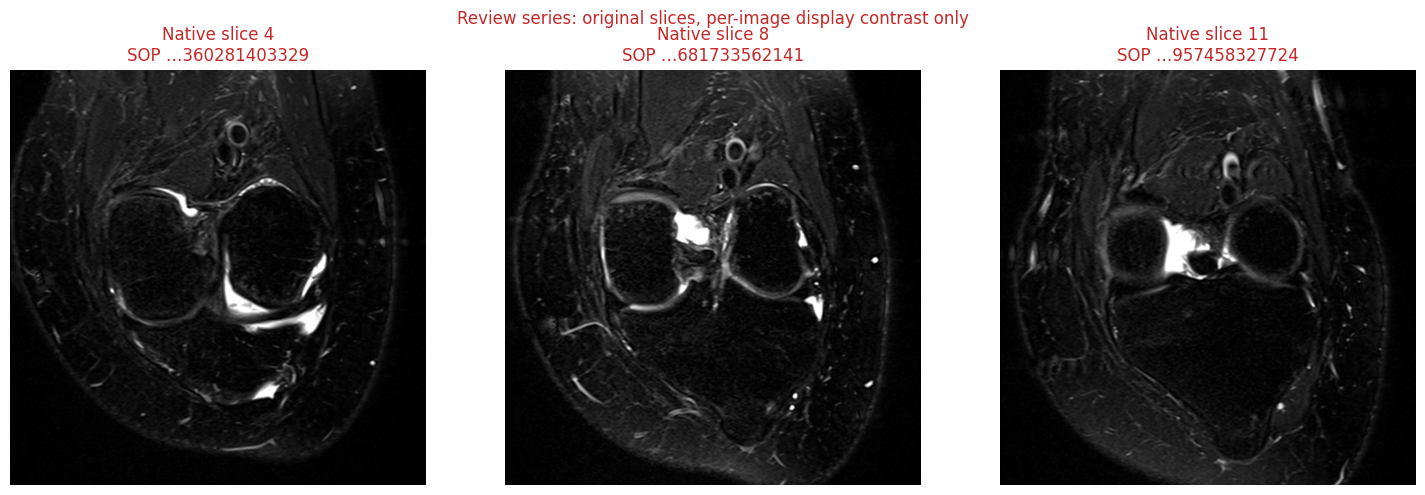

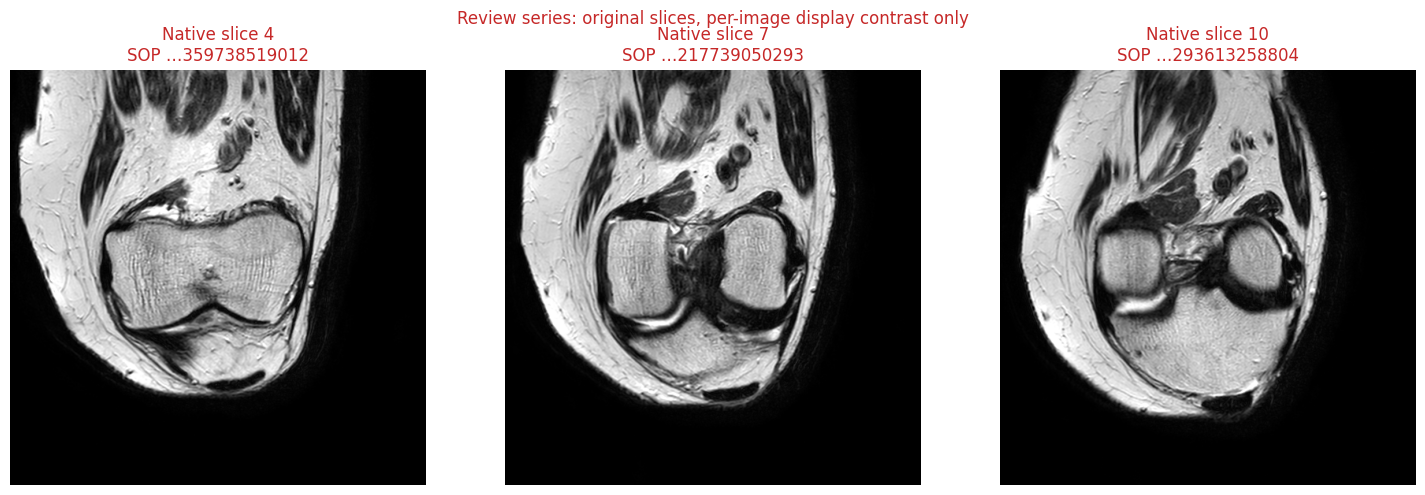

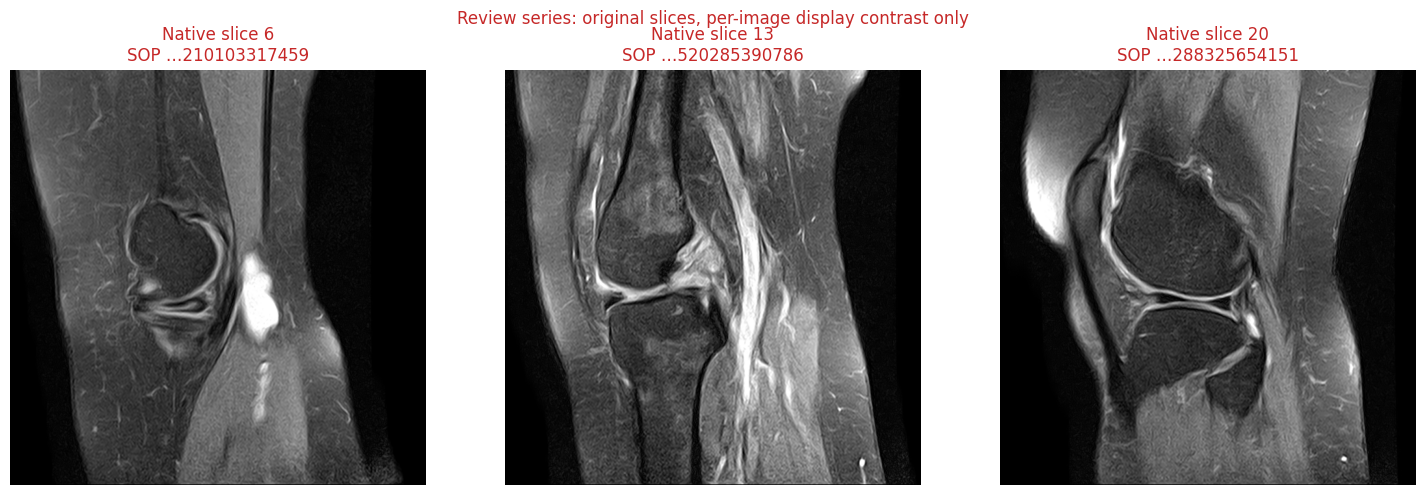

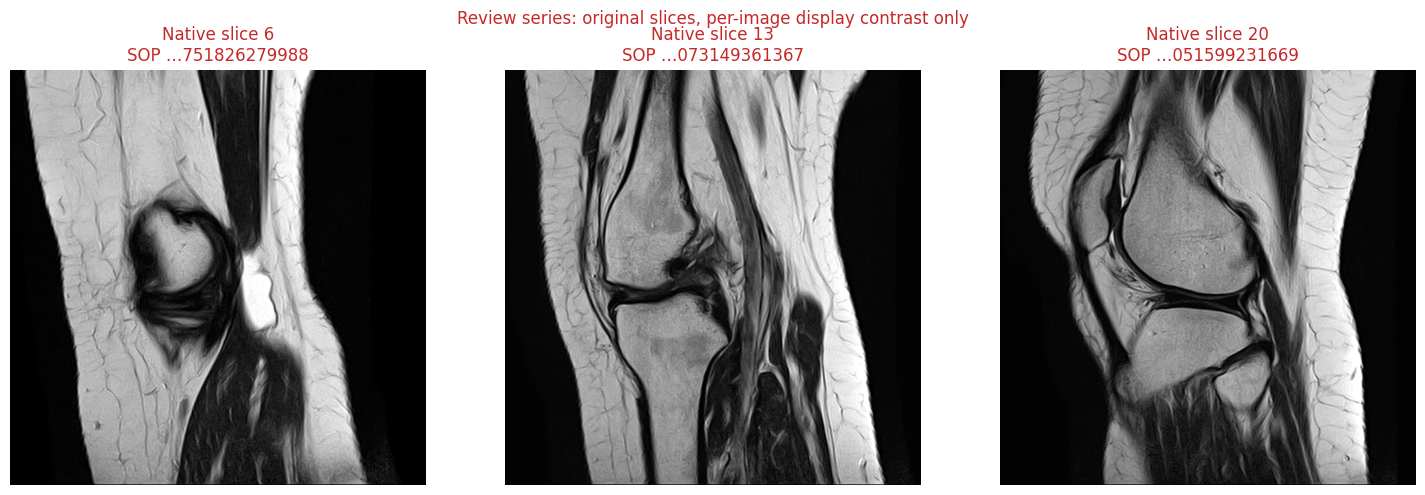

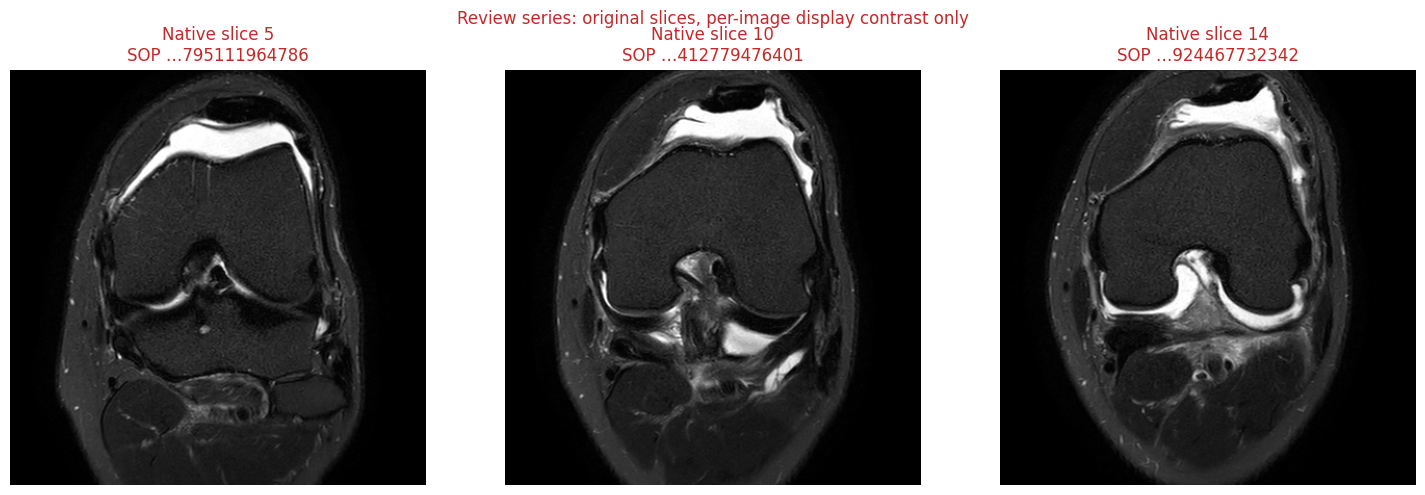

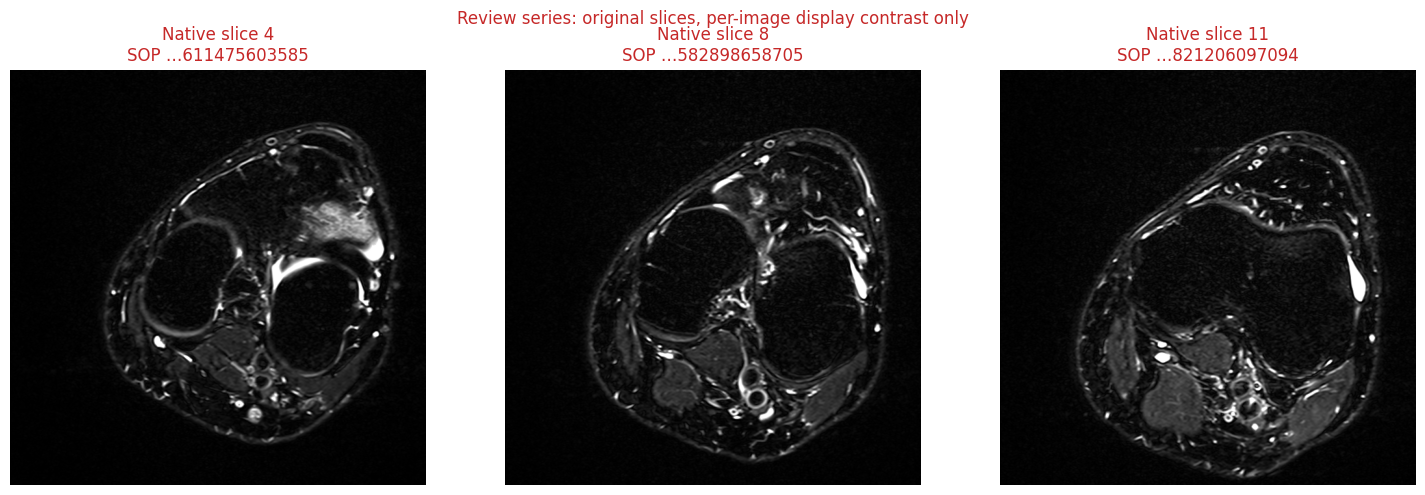

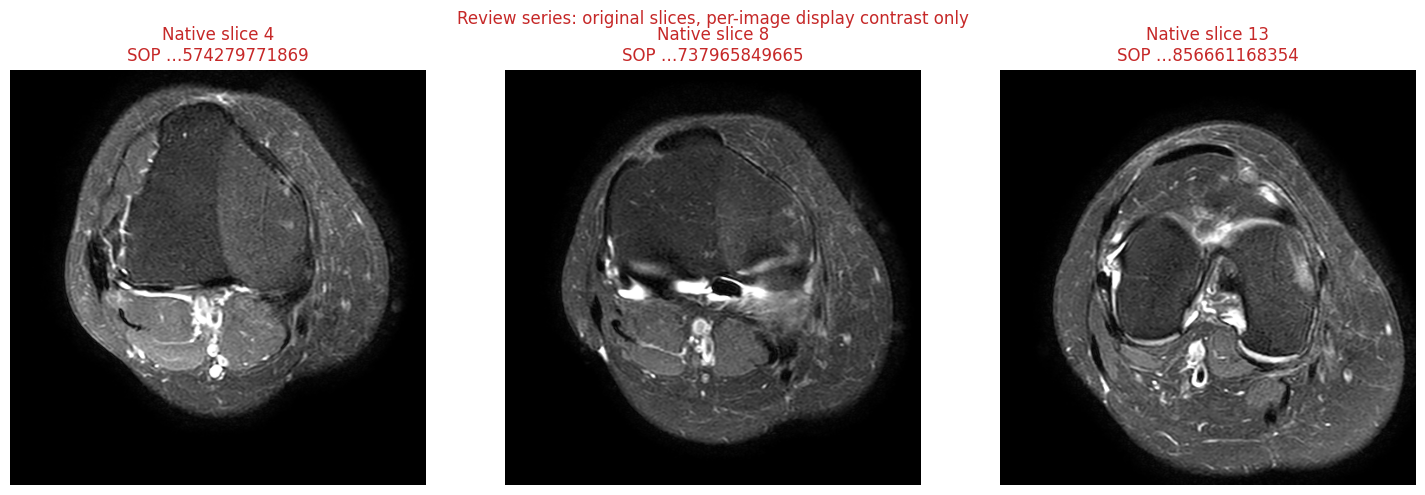

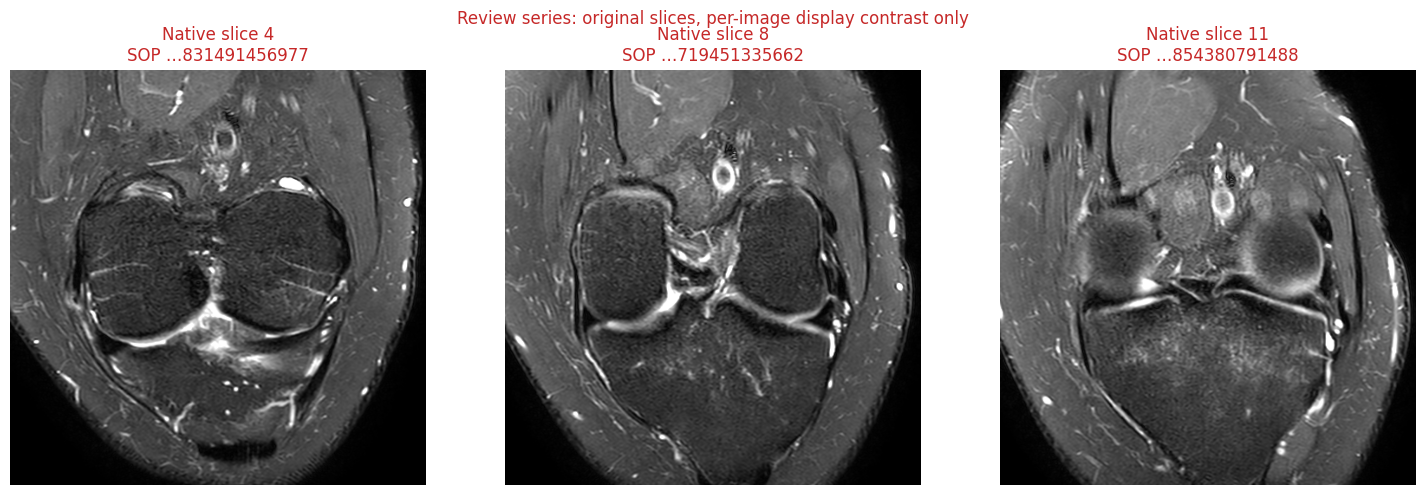

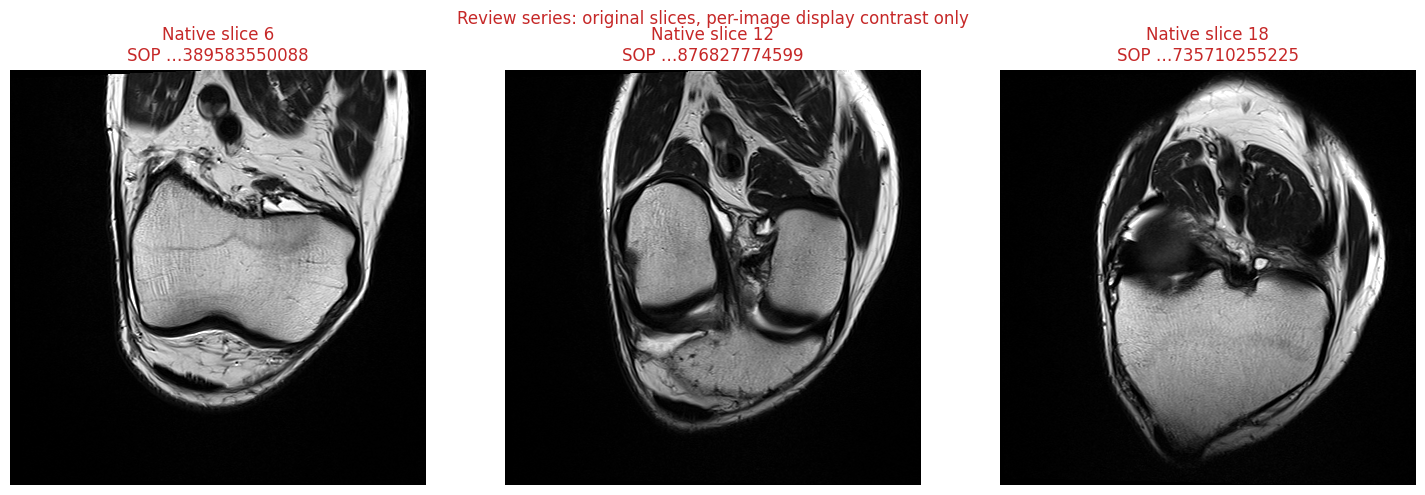

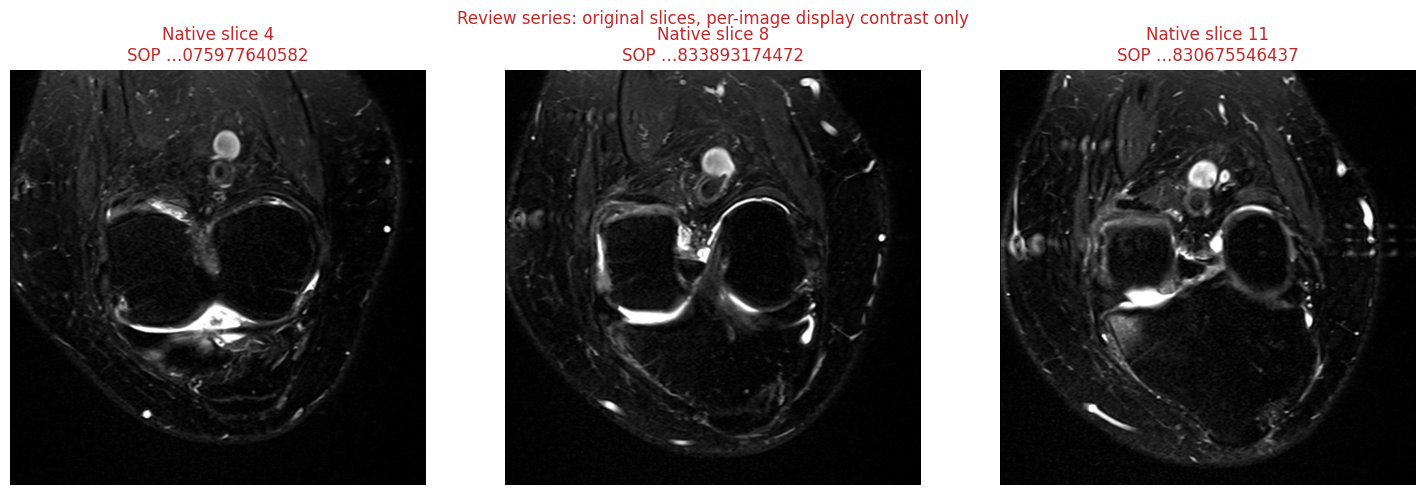

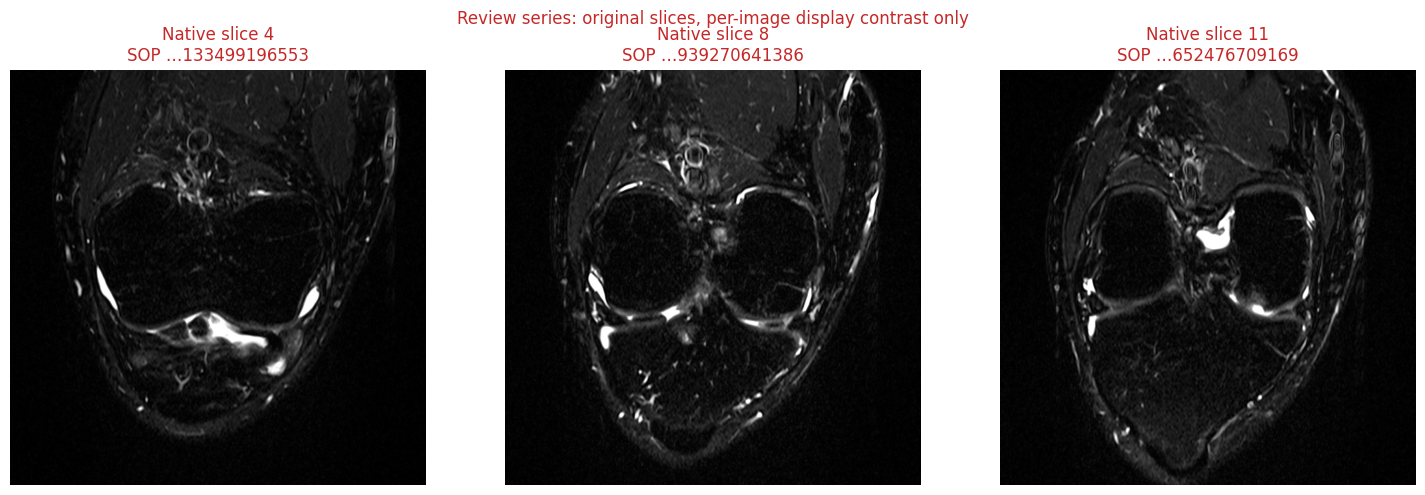

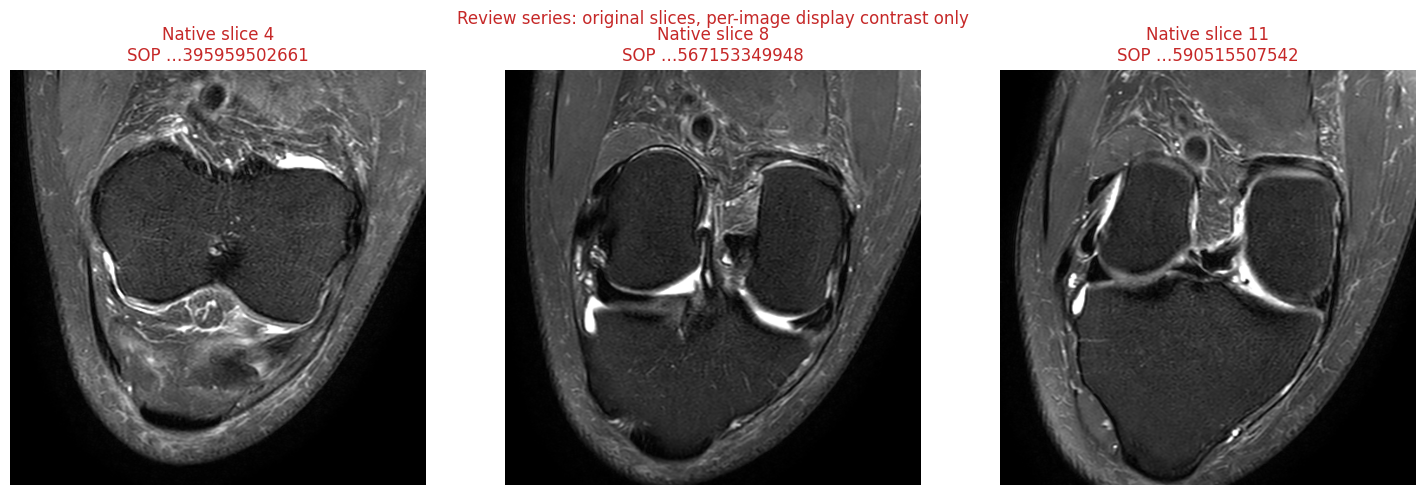

In [47]:
# Display errors first, then accepted orientation warnings. All rows are saved in CSV.
review_candidates=manifest.loc[manifest.status.eq('error') | manifest.needs_review.eq(True)].copy()
review_candidates['_error_first']=review_candidates.status.eq('error')
review_candidates=review_candidates.sort_values('_error_first',ascending=False,kind='stable')
if review_candidates.empty:
    red_diagnostic('No series errors or orientation warnings in this manifest.')
for _, review_record in review_candidates.head(REVIEW_PREVIEW_LIMIT).iterrows():
    show_review_series(review_record)
if len(review_candidates)>REVIEW_PREVIEW_LIMIT:
    red_diagnostic(f'Showing {REVIEW_PREVIEW_LIMIT} of {len(review_candidates)} flagged series. All are listed in the review CSV; increase REVIEW_PREVIEW_LIMIT to view more.')


## 6. What the displayed images represent

These are **preprocessing quality checks**, not model predictions or marked abnormalities. Each row comes from one successfully processed MRI series. The notebook selects one example for each available combination of plane, fluid sensitivity and fat suppression; it does not show every study or a flagged series.

From left to right:

1. **Native source:** an acquired slice near the middle of the series, before spatial resizing/orientation changes. Its brightness uses the same intensity normalization as the comparison, so this is not a raw-pixel display.
2. **Same SOP, normalized:** that exact same acquired image after in-plane resizing, orientation adjustment and padding. SOP identifies an individual DICOM image. Compare panels 1 and 2 for detail and anatomy coverage.
3. **Source at about one-quarter of the selected stack:** a different actual slice from the same series, after normalization.
4. **Source at about three-quarters of the selected stack:** another actual slice, after normalization.

Source numbers are zero-based positions in the spatially sorted original series. The last two panels are farther apart through the knee; they are not before/after pairs. `Retained 35/35`, for example, means all 35 acquired slices were retained. Padded slice slots are never displayed.

The row title identifies the plane and acquisition flags. Black margins may include added padding as well as background already present in the acquisition. Check sharpness, anatomy coverage, contrast and consistent orientation. These montages cannot establish diagnostic accuracy.

Images are saved under `qc/`; keep them within the competition's data rules.


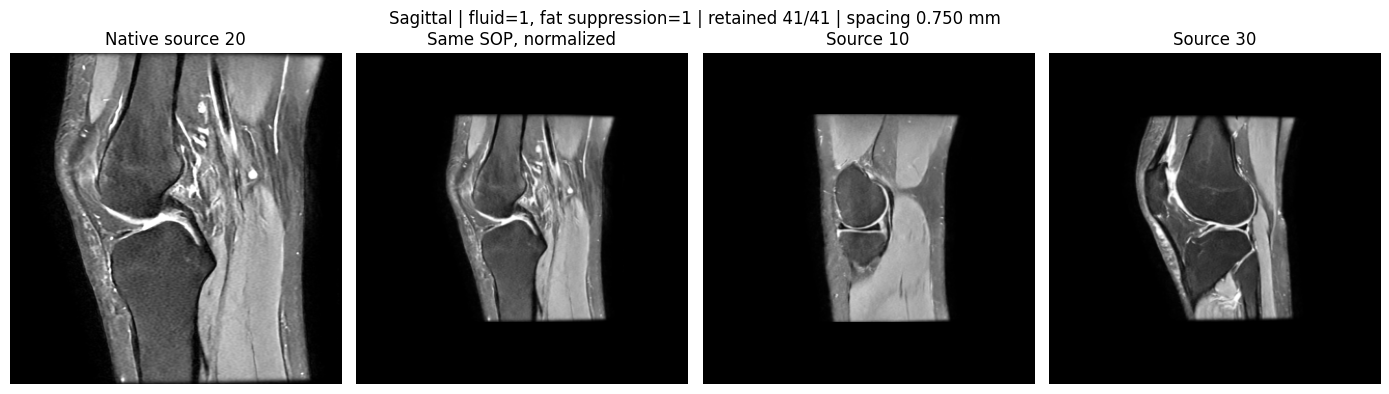

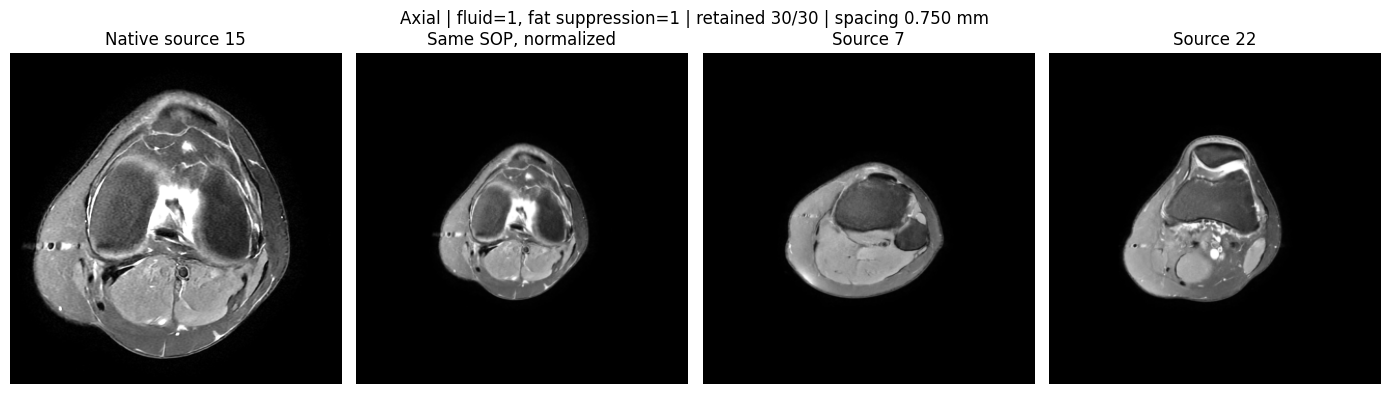

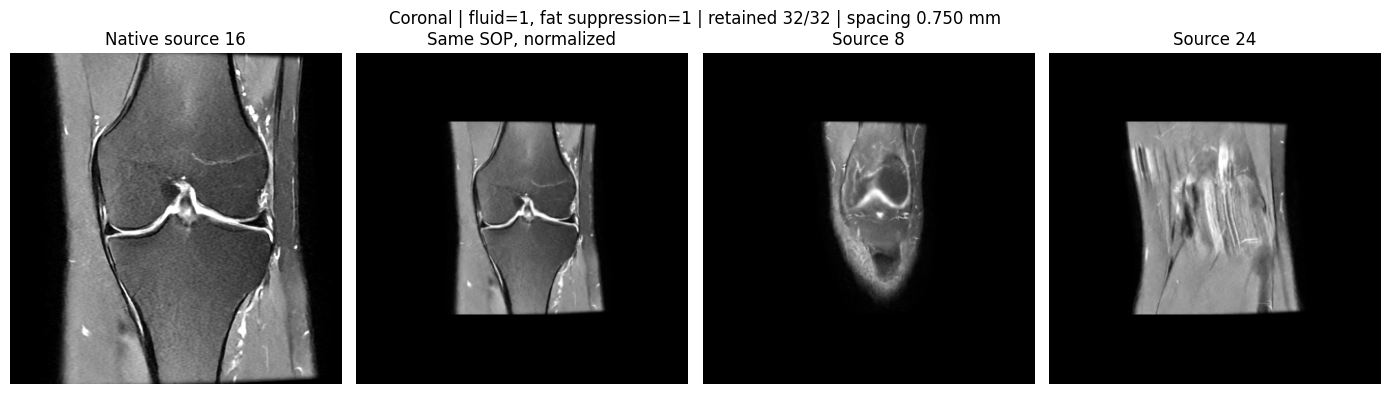

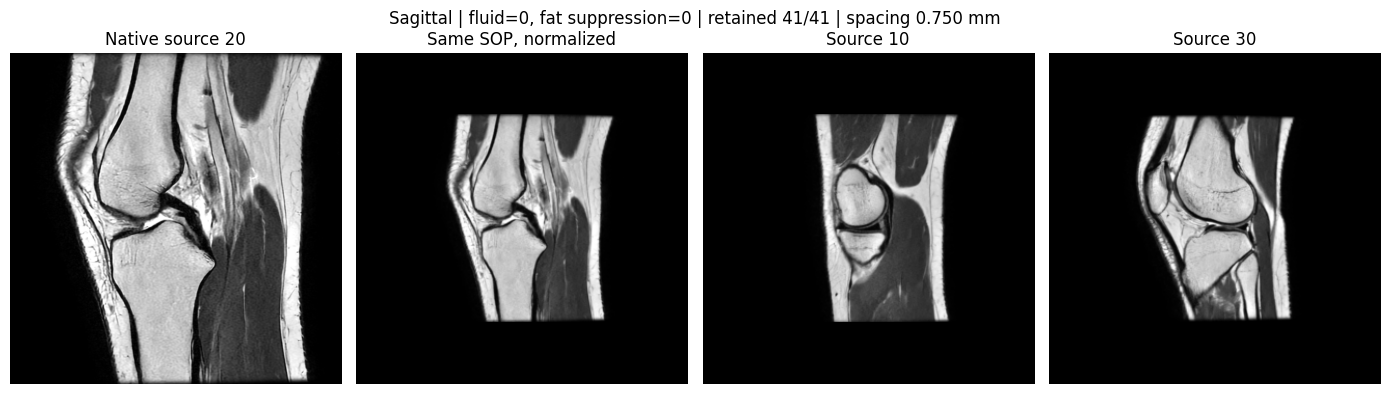

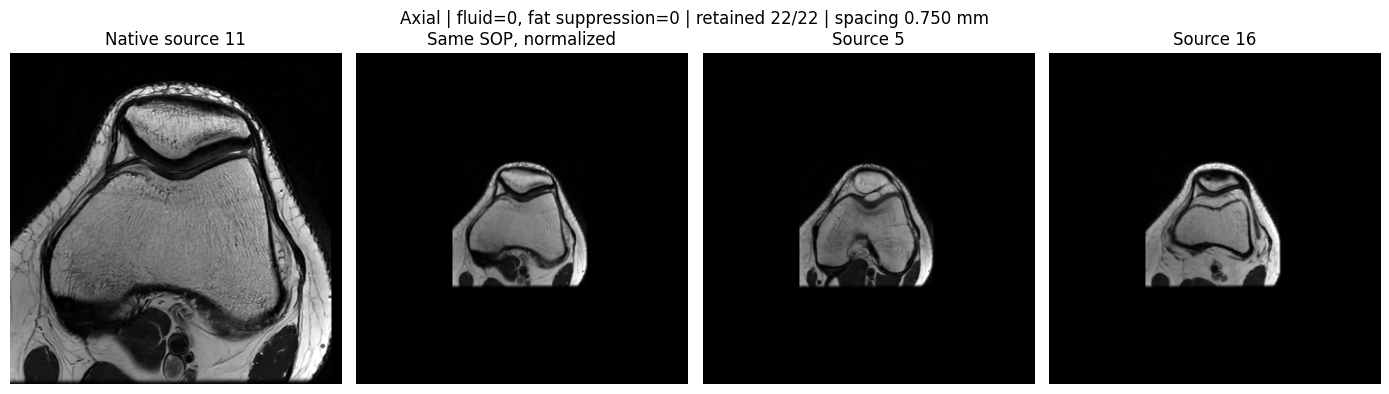

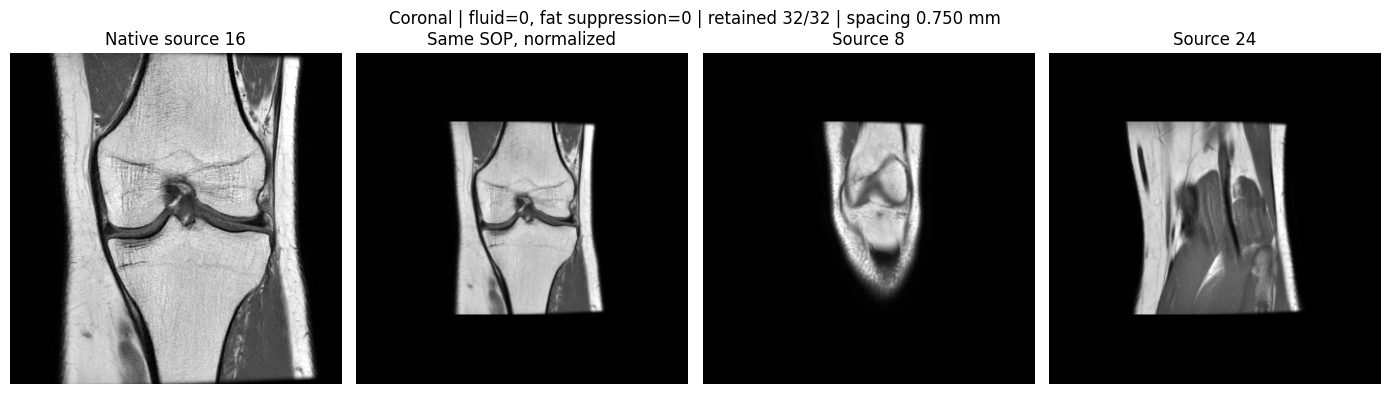

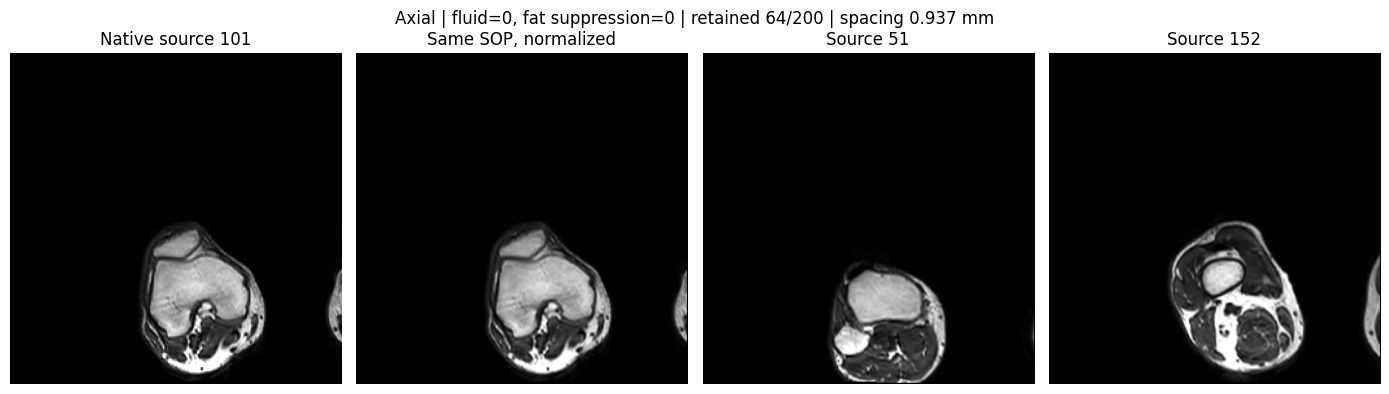

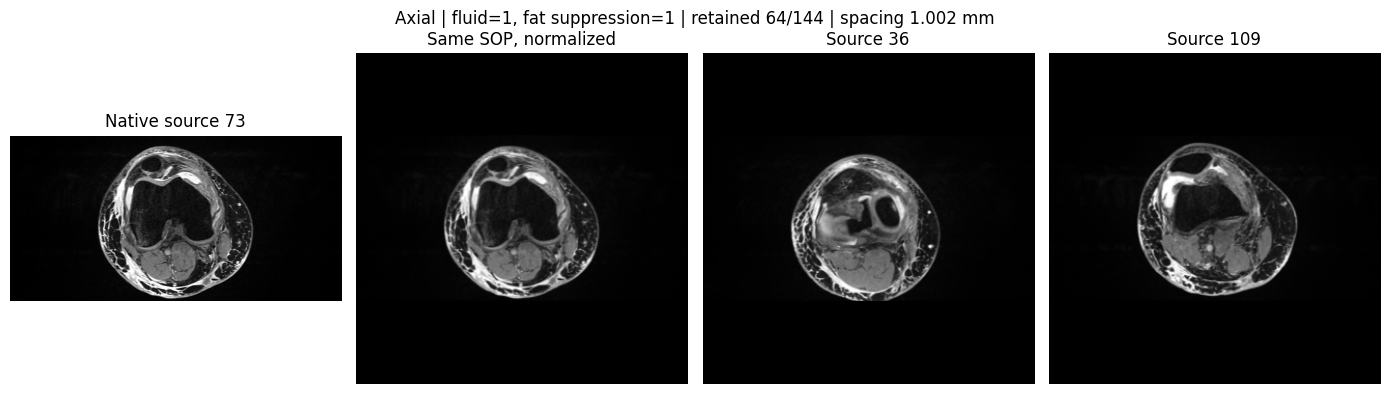

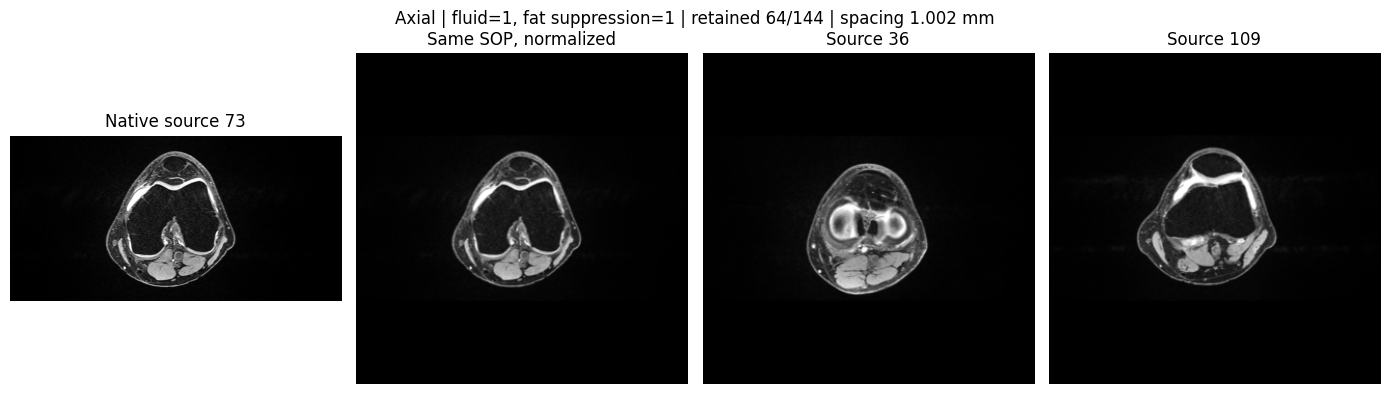

In [48]:
import matplotlib.pyplot as plt
qc=OUTPUT_DIR/'qc';qc.mkdir(exist_ok=True)
examples=manifest[manifest.status.eq('ok')].groupby(['Anatomical_Plane','Fluid_Sensitive','Fat_Suppression'],group_keys=False).head(1)
examples=pd.concat([examples,manifest[manifest.status.eq('ok') & manifest.fov_spacing_adjusted.eq(True)].head(3)]).drop_duplicates(SID)
for _,r in examples.iterrows():
    image,valid,meta=load_cache(r.cache_path,RUN_ID)
    folder=DATA_DIR/'train_series'/r[ID]/r[SID]
    count=meta['selected_count'];middle=count//2
    sop=meta['selected_sop_uids'][middle];source_path=folder/(sop+'.dcm')
    if not source_path.exists():
        source_path=next(p for p in folder.glob('*.dcm') if str(pydicom.dcmread(p,stop_before_pixels=True).SOPInstanceUID)==sop)
    source,source_valid=decode_native_slice(source_path)
    ds=pydicom.dcmread(source_path,stop_before_pixels=True)
    source=np.clip((source-meta['intensity_low'])/(meta['intensity_high']-meta['intensity_low']),0,1)
    if ds.PhotometricInterpretation=='MONOCHROME1':source=1-source
    source[~source_valid]=0
    fig,ax=plt.subplots(1,4,figsize=(14,4))
    ax[0].imshow(source,cmap='gray',vmin=0,vmax=1)
    ax[0].set_title(f"Native source {meta['selected_source_indices'][middle]}")
    for a,k in zip(ax[1:],[middle,count//4,3*count//4]):
        a.imshow(image[k],cmap='gray',vmin=0,vmax=1)
        a.set_title(('Same SOP, normalized' if k==middle else f"Source {meta['selected_source_indices'][k]}"))
    for a in ax:a.axis('off')
    fig.suptitle(f'{r.Anatomical_Plane} | fluid={r.Fluid_Sensitive}, fat suppression={r.Fat_Suppression} | retained {count}/{meta["input_shape"][0]} | spacing {meta["spacing_summary_drc_mm"][1]:.3f} mm')
    fig.tight_layout();fig.savefig(qc/f'{r[SID]}.png',dpi=120);plt.show();plt.close(fig)


## 7. Training integration and one-batch smoke check

Start with batch size 1 and `num_workers=0`. A study can contain 14 series, so even normalized data can use substantial RAM/VRAM. Feed slice images through a shared encoder, pool valid slices into series features, and pool valid series into **one** study vector. Masks and protocol/spacing metadata are available for that aggregation.

The example below validates the loader and loss on dummy logits. It does not establish model performance. Validation uses verified targets only. Never train on held-out studies even where a report-derived label exists.

In [49]:
train_dataset=KneeStudyDataset(training_series,labels,'train',VALIDATION_FOLD)
validation_dataset=KneeStudyDataset(training_series,labels,'validation',VALIDATION_FOLD)
assert set(train_dataset.ids).isdisjoint(validation_dataset.ids)
indexed=labels.set_index(ID)
assert set(indexed.loc[train_dataset.ids,'patient_group']).isdisjoint(
    set(indexed.loc[validation_dataset.ids,'patient_group']))
print('Train/validation studies:',len(train_dataset),len(validation_dataset))
if MAX_STUDIES is not None:
    assert len(train_dataset)>0 and len(validation_dataset)>0, 'Pilot incomplete: inspect failed studies; expand/reselect pilot before scaling'
if len(validation_dataset):
    vb=next(iter(DataLoader(validation_dataset,batch_size=1,num_workers=0,collate_fn=collate_studies)))
    assert vb['label_mask'].any() and torch.isfinite(vb['images']).all()
    print('Verified validation batch passed:',vb['study_ids'])
if len(train_dataset):
    loader=DataLoader(train_dataset,batch_size=1,shuffle=True,num_workers=0,collate_fn=collate_studies)
    batch=next(iter(loader))
    print({k:tuple(v.shape) for k,v in batch.items() if torch.is_tensor(v)})
    assert torch.isfinite(batch['images']).all()
    assert batch['images'].min()>=0 and batch['images'].max()<=1
    logits=torch.zeros_like(batch['targets'],requires_grad=True)
    loss=masked_weighted_bce(logits,batch['targets'],batch['label_mask'],batch['weights'])
    loss.backward();assert torch.isfinite(loss)
    print('Loader/loss smoke check passed:',float(loss.detach()))
else:
    print('No eligible labeled training studies in this pilot. Inspect QC and select a larger shard.')
if not len(validation_dataset):print('No validation studies in this pilot; evaluate after combining sufficient shards.')

Train/validation studies: 281 1
Verified validation batch passed: ['1.2.826.0.1.3680043.8.498.26790702379506190936834447203448882465']
{'images': (1, 5, 64, 320, 320), 'voxel_mask': (1, 5, 64, 320, 320), 'series_mask': (1, 5), 'slice_mask': (1, 5, 64), 'protocol': (1, 5, 3), 'spacing': (1, 5, 3), 'slice_positions_mm': (1, 5, 64), 'targets': (1, 12), 'label_mask': (1, 12), 'weights': (1, 12)}
Loader/loss smoke check passed: 0.6931471824645996


## 8. Train directly from the published dataset

Attach `gany24558/rsna-knee-normalized-training-data` once Kaggle finishes processing its latest version. Set the root below to the mounted folder containing `dataset_index.json`. The dataset contains one `.tar.bin` package per shard; these are ordinary tar archives with a binary suffix to preserve them as files. The loader reads individual NPZ members directly, without unpacking the full dataset.

Run the helper-definition cells in your training notebook. The loader checks that all shards are present and processed, and that labels, preprocessing and shard plans match. It rejects partial snapshots. Within processed shards, recorded errors still exclude incomplete studies. Review those errors before model training.

In [38]:
from pathlib import Path

PUBLISHED_DATASET_ROOT = Path(
    '/kaggle/input/datasets/gany24558/rsna-knee-normalized-training-data'
)

assert (PUBLISHED_DATASET_ROOT / 'dataset_index.json').is_file(), \
    "Check the dataset path in Kaggle's Input panel."

combined_series, published_labels = load_published_dataset(
    PUBLISHED_DATASET_ROOT
)

train_dataset = KneeStudyDataset(
    combined_series, published_labels, 'train', VALIDATION_FOLD
)
validation_dataset = KneeStudyDataset(
    combined_series, published_labels, 'validation', VALIDATION_FOLD
)

print(
    'Published training / validation studies:',
    len(train_dataset), len(validation_dataset)
)

Published training / validation studies: 3905 12


## Boundaries and next checks

- Native obliquity remains. This is a 2.5D representation, not registered or isotropic 3D data. Use the true slice positions and masks if the model uses positional information; `spacing` contains only a median depth-gap summary.
- Long series still lose slices when sampled. Review `retained_slice_fraction` and `slice_gap_max_mm`; increase depth or use variable-length sampling if needed. Padding does not count as acquired data.
- In-plane downsampling and anti-aliasing still reduce resolution. Compare matched SOP images before expanding the run.
- QC failures exclude incomplete studies. Pilot selection guarantees candidate verified studies, not successful preprocessing. A missing validation loader now fails the pilot check visibly.
- Patient grouping is used only when patient identifiers are supplied. Study-disjoint folds alone cannot prove patient independence. The reused gold labels remain developmental evidence.
- A training model must mask both padded slices and padded series. Validation uses only verified targets; reports are never inference inputs.
- Save cache shards and rebase paths after mounting outputs. Use the identical native-plane preprocessing for test inference; define a separate tested fallback for failed test studies.

References: [pydicom pixel processing](https://pydicom.github.io/pydicom/stable/tutorials/pixel_data/introduction.html), [compressed pixel support](https://pydicom.github.io/pydicom/stable/guides/user/image_data_handlers.html), [SciPy affine transform](https://docs.scipy.org/doc/scipy/reference/generated/scipy.ndimage.affine_transform.html).